<a href="https://www.kaggle.com/code/omborse771924/inzaghi-fashion-ai-dataset-eda-features-engineerig?scriptVersionId=332932261" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/wardaadann/inzaghi-ai-castle/fashion_dataset_complete.csv


## Features Engineering

In [2]:
df = pd.read_csv('/kaggle/input/datasets/wardaadann/inzaghi-ai-castle/fashion_dataset_complete.csv')

In [3]:
df.head()

,user_id,session_id,timestamp,gender,age_group,body_type,skin_tone,height,style_preference,budget_level,...,saves,tryon_count,purchased,embedding_1,embedding_2,embedding_3,month,total_score,recommendation_priority,outfit_description
0,INZ_000000,c807fc10dcbc,2023-04-23,Non-binary,45-54,Apple,Light,"6'0""-6'2""",Minimalist,Premium,...,9,19,0,-0.2158,-0.5682,2.1110,4,0.646,High,Minimalist T-shirt in Navy - Perfect for Formal
1,INZ_000001,1d95c3f54b1e,2023-06-23,Gender-fluid,45-54,Hourglass,Tan,"6'0""-6'2""",Romantic,Mid-range,...,17,7,0,-1.3490,-0.2519,0.6696,6,0.720,High,Romantic Shorts in Gray - Perfect for Vacation
2,INZ_000002,51f132eee770,2023-11-22,Female,35-44,Athletic,Dark,"6'0""-6'2""",Bohemian,Mid-range,...,11,8,0,-0.1628,0.1518,0.3025,11,0.760,High,Bohemian Top in White - Perfect for Brunch
3,INZ_000003,6b75503a364f,2023-01-24,Non-binary,18-24,Inverted Triangle,Dark,"5'6""-5'8""",Streetwear,Luxury,...,7,11,0,0.7484,-1.3508,0.8619,1,0.581,Medium,Streetwear Jeans in Navy - Perfect for Formal
4,INZ_000004,94ec485a2997,2023-06-07,Non-binary,25-34,Rectangle,Dark,"5'6""-5'8""",Edgy,Premium,...,15,11,0,0.3239,-0.6195,1.8628,6,0.664,High,Edgy Jeans in Beige - Perfect for Wedding


In [4]:
df.tail()

,user_id,session_id,timestamp,gender,age_group,body_type,skin_tone,height,style_preference,budget_level,...,saves,tryon_count,purchased,embedding_1,embedding_2,embedding_3,month,total_score,recommendation_priority,outfit_description
10495,INZ_010495,7552d926d280,2023-05-22,Non-binary,55+,Inverted Triangle,Light,"5'9""-5'11""",Streetwear,Luxury,...,8,7,0,-0.9260,-3.5313,0.5991,5,0.594,Medium,Streetwear Pants in Black - Perfect for Casual
10496,INZ_010496,f095483fba8c,2023-10-24,Gender-fluid,45-54,Hourglass,Fair,"5'3""-5'5""",Minimalist,Luxury,...,12,10,0,1.2025,-0.4055,-1.0266,10,0.587,Medium,Minimalist Jacket in Yellow - Perfect for Party
10497,INZ_010497,b13942f7ce6d,2023-08-19,Gender-fluid,55+,Apple,Light,"5'3""-5'5""",Edgy,Premium,...,10,4,0,-1.6801,-0.4680,-1.0694,8,0.573,Medium,Edgy Jeans in Navy - Perfect for Gym
10498,INZ_010498,70c929043745,2023-05-26,Gender-fluid,25-34,Hourglass,Tan,"5'3""-5'5""",Classic,Budget,...,12,8,0,-0.0226,0.9774,-0.5769,5,0.669,High,Classic Shorts in Green - Perfect for Party
10499,INZ_010499,349457ba6f14,2023-04-26,Male,35-44,Apple,Light,"6'0""-6'2""",Edgy,Mid-range,...,11,11,0,-1.0110,0.2196,0.2064,4,0.402,Medium,Edgy Dress in Black - Perfect for Formal


In [5]:
df.info

<bound method DataFrame.info of           user_id    session_id   timestamp        gender age_group  \
0      INZ_000000  c807fc10dcbc  2023-04-23    Non-binary     45-54   
1      INZ_000001  1d95c3f54b1e  2023-06-23  Gender-fluid     45-54   
2      INZ_000002  51f132eee770  2023-11-22        Female     35-44   
3      INZ_000003  6b75503a364f  2023-01-24    Non-binary     18-24   
4      INZ_000004  94ec485a2997  2023-06-07    Non-binary     25-34   
...           ...           ...         ...           ...       ...   
10495  INZ_010495  7552d926d280  2023-05-22    Non-binary       55+   
10496  INZ_010496  f095483fba8c  2023-10-24  Gender-fluid     45-54   
10497  INZ_010497  b13942f7ce6d  2023-08-19  Gender-fluid       55+   
10498  INZ_010498  70c929043745  2023-05-26  Gender-fluid     25-34   
10499  INZ_010499  349457ba6f14  2023-04-26          Male     35-44   

               body_type skin_tone      height style_preference budget_level  \
0                  Apple     Light 

In [6]:

df.isnull()

,user_id,session_id,timestamp,gender,age_group,body_type,skin_tone,height,style_preference,budget_level,...,saves,tryon_count,purchased,embedding_1,embedding_2,embedding_3,month,total_score,recommendation_priority,outfit_description
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10495,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10497,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

user_id                    0
session_id                 0
timestamp                  0
gender                     0
age_group                  0
body_type                  0
skin_tone                  0
height                     0
style_preference           0
budget_level               0
preferred_brand            0
clothing_type              0
fabric                     0
primary_color              0
pattern                    0
occasion                   0
mood                       0
season                     0
weather                    0
price_usd                  0
satisfaction_score         0
trend_score                0
comfort_score              0
sustainability_score       0
quality_score              0
fit_score                  0
views                      0
likes                      0
shares                     0
saves                      0
tryon_count                0
purchased                  0
embedding_1                0
embedding_2                0
embedding_3   

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe

<bound method NDFrame.describe of           user_id    session_id   timestamp        gender age_group  \
0      INZ_000000  c807fc10dcbc  2023-04-23    Non-binary     45-54   
1      INZ_000001  1d95c3f54b1e  2023-06-23  Gender-fluid     45-54   
2      INZ_000002  51f132eee770  2023-11-22        Female     35-44   
3      INZ_000003  6b75503a364f  2023-01-24    Non-binary     18-24   
4      INZ_000004  94ec485a2997  2023-06-07    Non-binary     25-34   
...           ...           ...         ...           ...       ...   
10495  INZ_010495  7552d926d280  2023-05-22    Non-binary       55+   
10496  INZ_010496  f095483fba8c  2023-10-24  Gender-fluid     45-54   
10497  INZ_010497  b13942f7ce6d  2023-08-19  Gender-fluid       55+   
10498  INZ_010498  70c929043745  2023-05-26  Gender-fluid     25-34   
10499  INZ_010499  349457ba6f14  2023-04-26          Male     35-44   

               body_type skin_tone      height style_preference budget_level  \
0                  Apple     Ligh

In [10]:
df.columns

Index(['user_id', 'session_id', 'timestamp', 'gender', 'age_group',
       'body_type', 'skin_tone', 'height', 'style_preference', 'budget_level',
       'preferred_brand', 'clothing_type', 'fabric', 'primary_color',
       'pattern', 'occasion', 'mood', 'season', 'weather', 'price_usd',
       'satisfaction_score', 'trend_score', 'comfort_score',
       'sustainability_score', 'quality_score', 'fit_score', 'views', 'likes',
       'shares', 'saves', 'tryon_count', 'purchased', 'embedding_1',
       'embedding_2', 'embedding_3', 'month', 'total_score',
       'recommendation_priority', 'outfit_description'],
      dtype='object')

## EDA


Dataset Shape
(10500, 39)
First Five Rows
      user_id    session_id   timestamp        gender age_group  \
0  INZ_000000  c807fc10dcbc  2023-04-23    Non-binary     45-54   
1  INZ_000001  1d95c3f54b1e  2023-06-23  Gender-fluid     45-54   
2  INZ_000002  51f132eee770  2023-11-22        Female     35-44   
3  INZ_000003  6b75503a364f  2023-01-24    Non-binary     18-24   
4  INZ_000004  94ec485a2997  2023-06-07    Non-binary     25-34   

           body_type skin_tone     height style_preference budget_level  ...  \
0              Apple     Light  6'0"-6'2"       Minimalist      Premium  ...   
1          Hourglass       Tan  6'0"-6'2"         Romantic    Mid-range  ...   
2           Athletic      Dark  6'0"-6'2"         Bohemian    Mid-range  ...   
3  Inverted Triangle      Dark  5'6"-5'8"       Streetwear       Luxury  ...   
4          Rectangle      Dark  5'6"-5'8"             Edgy      Premium  ...   

  saves tryon_count purchased embedding_1 embedding_2 embedding_3 month  \

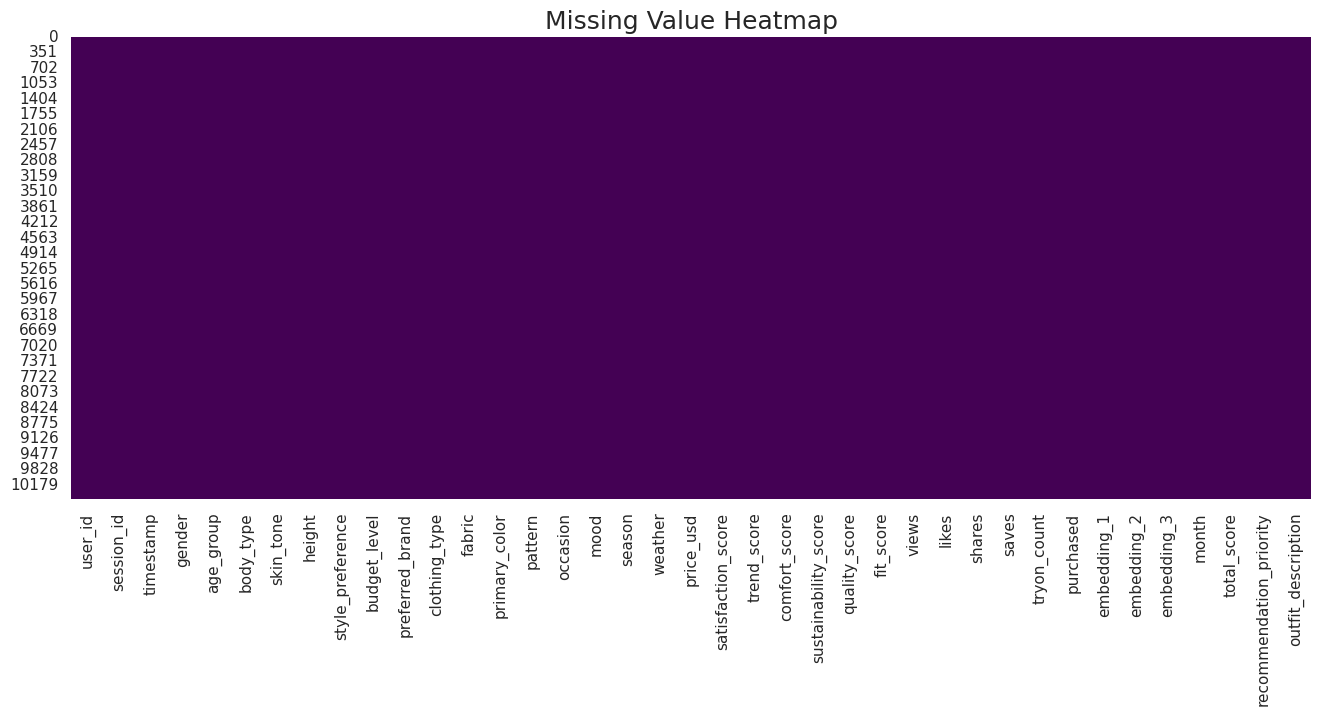

Index(['price_usd', 'satisfaction_score', 'trend_score', 'comfort_score',
       'sustainability_score', 'quality_score', 'fit_score', 'views', 'likes',
       'shares', 'saves', 'tryon_count', 'purchased', 'embedding_1',
       'embedding_2', 'embedding_3', 'month', 'total_score'],
      dtype='object')
Index(['user_id', 'session_id', 'timestamp', 'gender', 'age_group',
       'body_type', 'skin_tone', 'height', 'style_preference', 'budget_level',
       'preferred_brand', 'clothing_type', 'fabric', 'primary_color',
       'pattern', 'occasion', 'mood', 'season', 'weather',
       'recommendation_priority', 'outfit_description'],
      dtype='object')


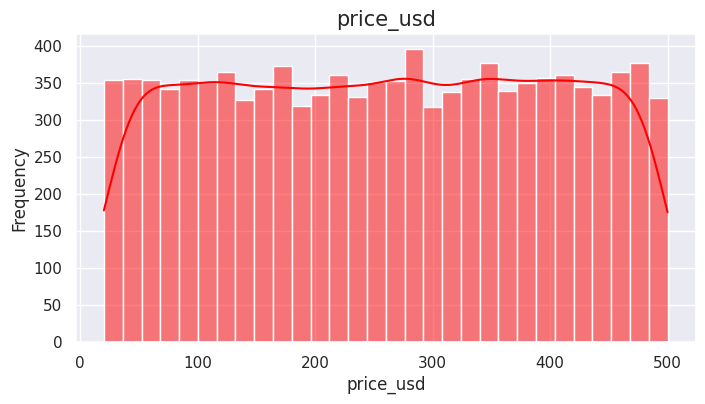

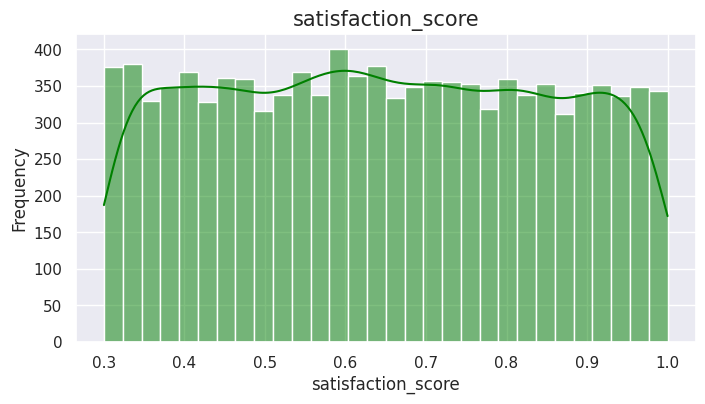

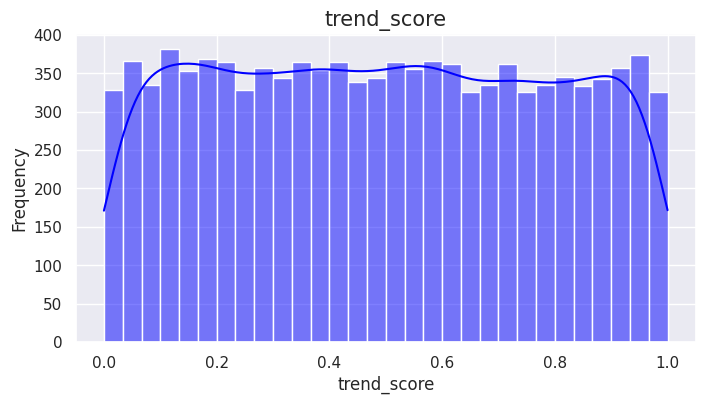

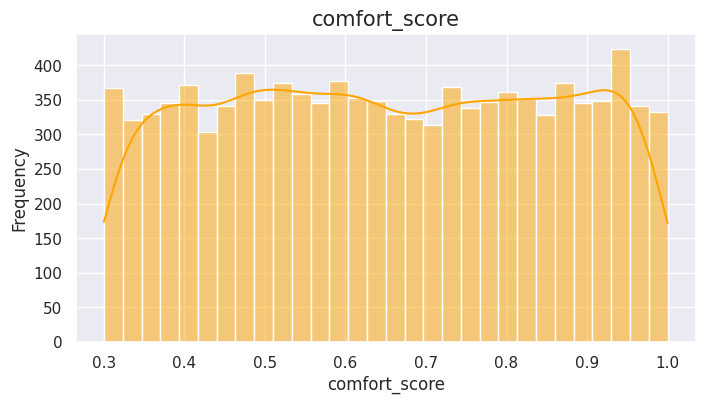

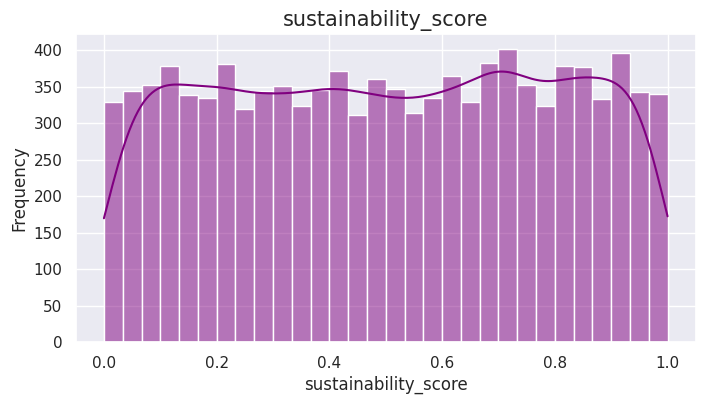

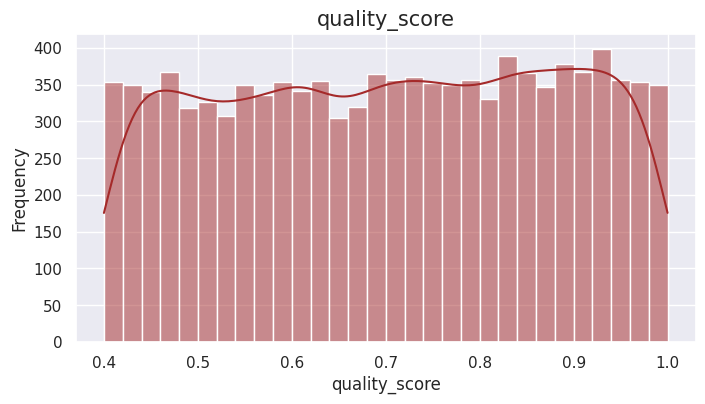

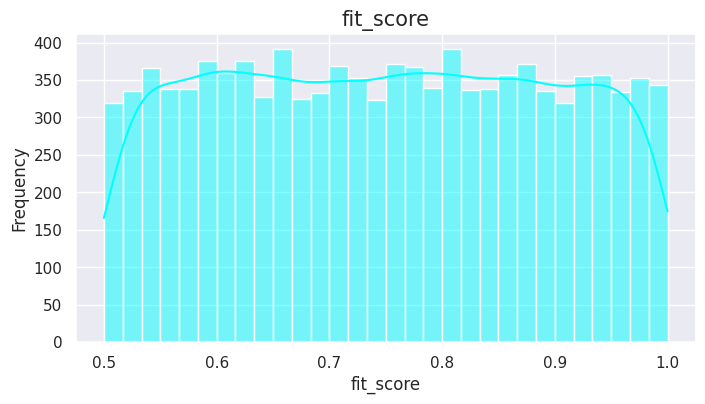

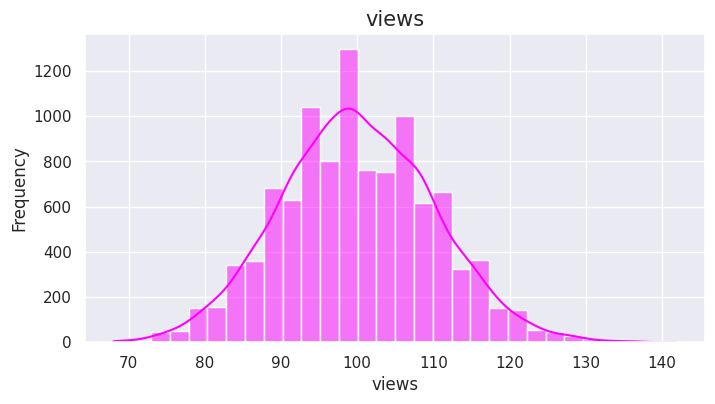

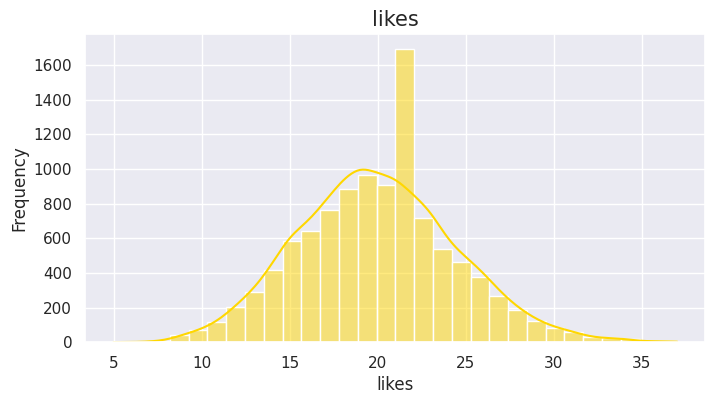

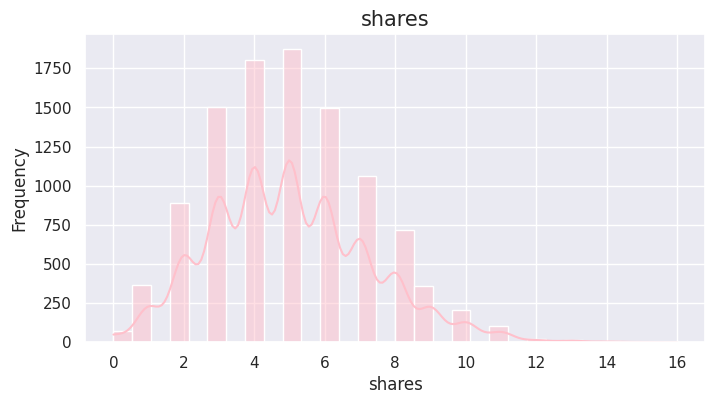

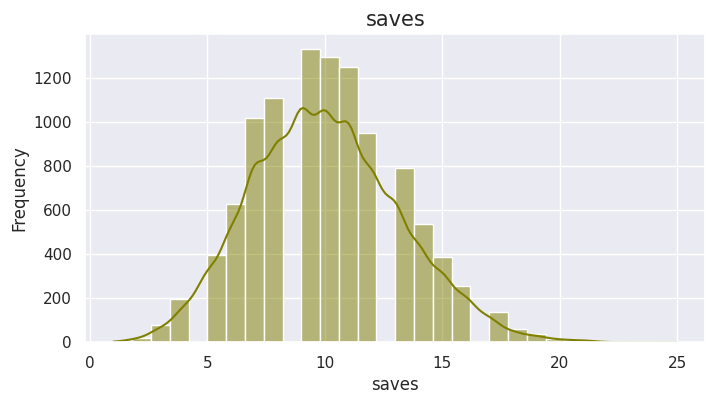

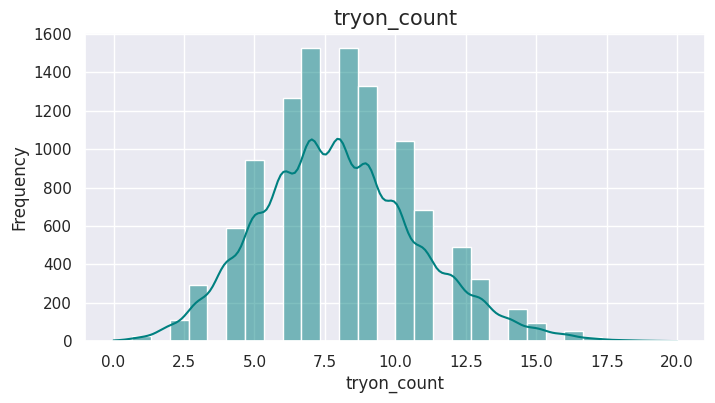

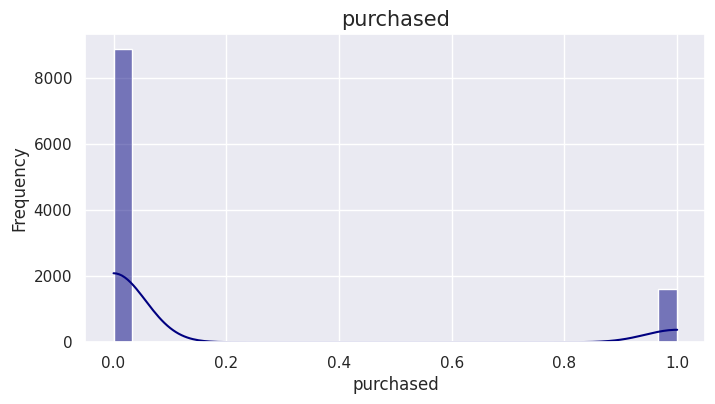

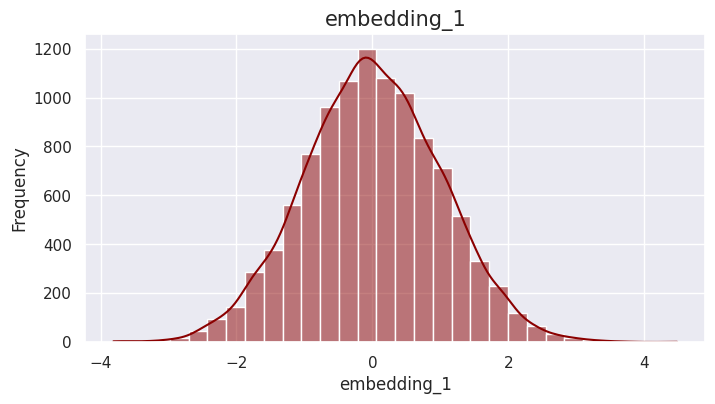

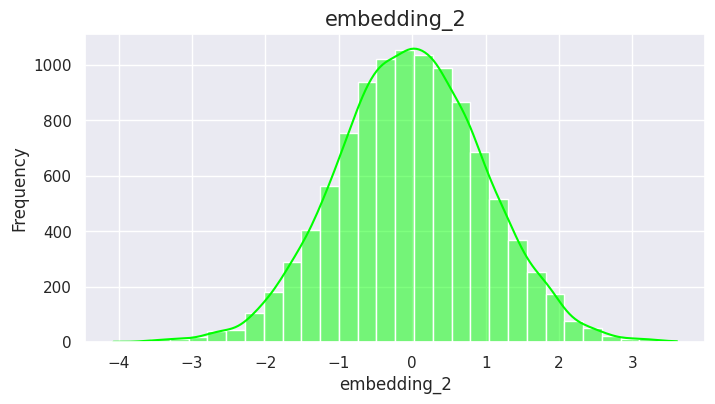

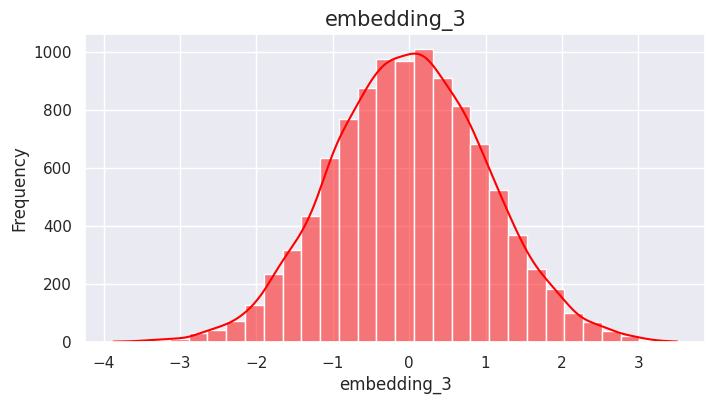

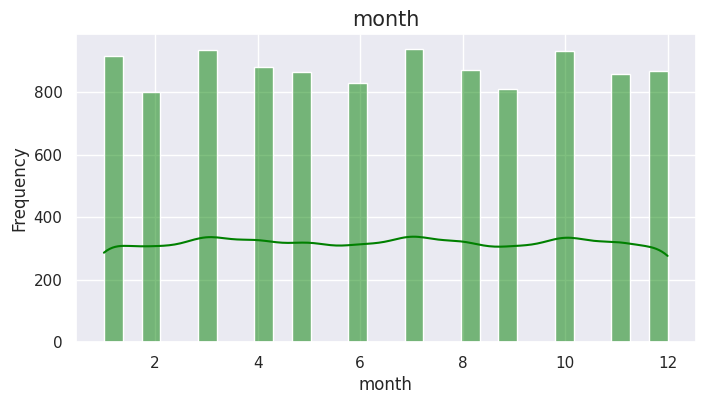

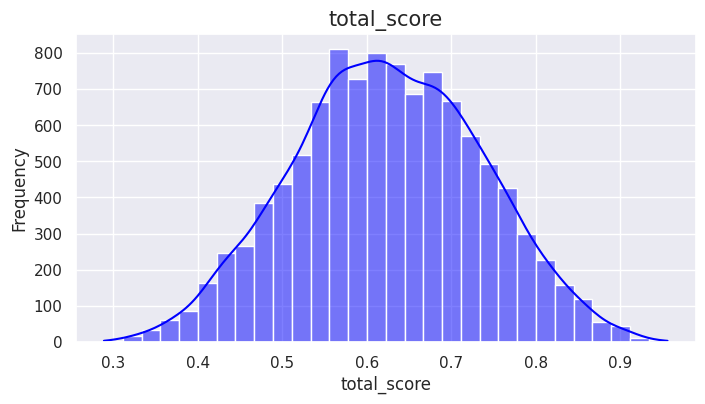

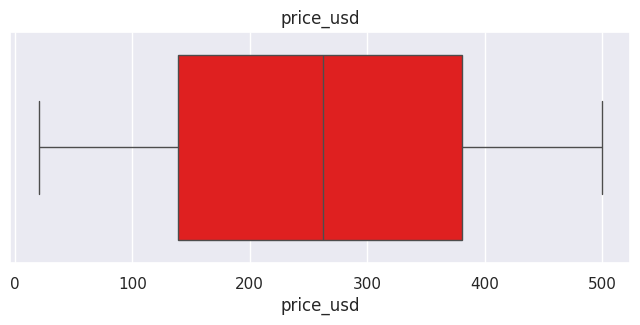

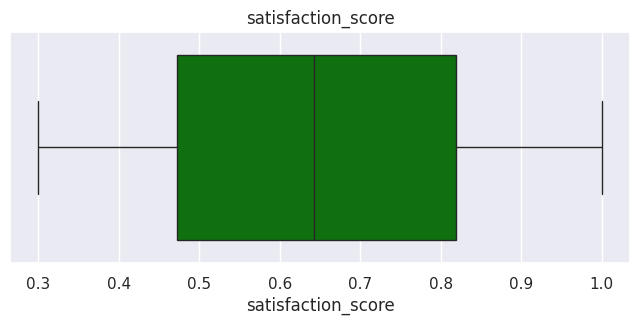

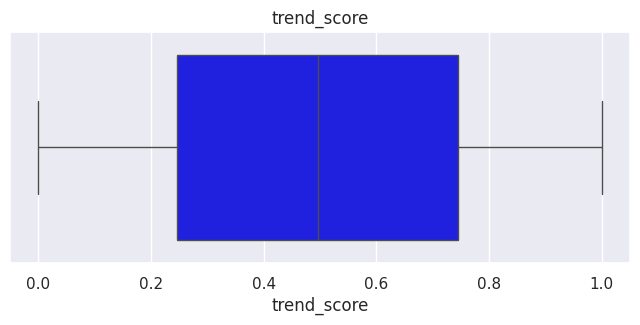

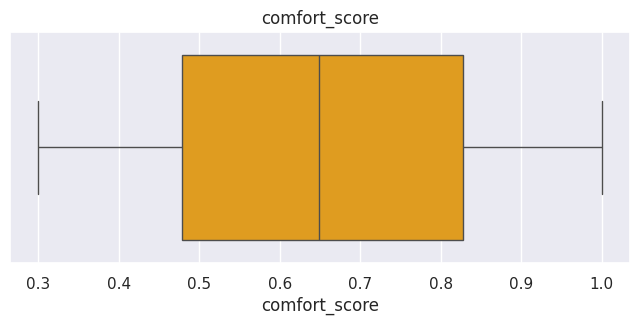

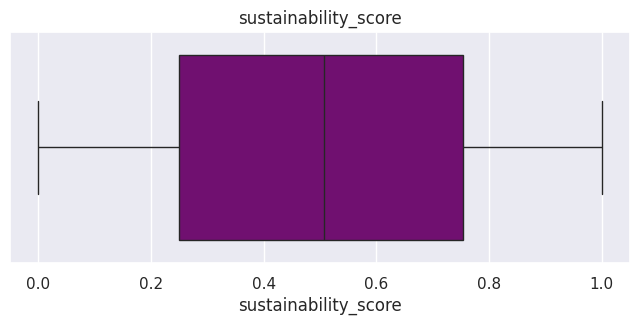

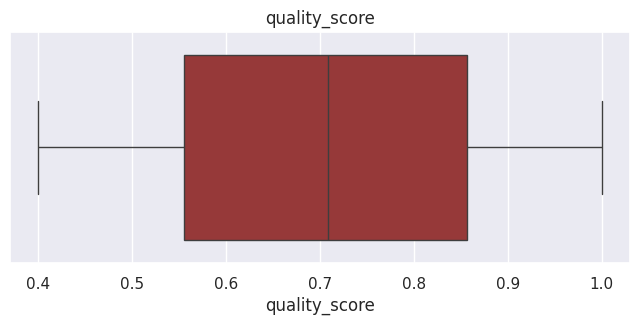

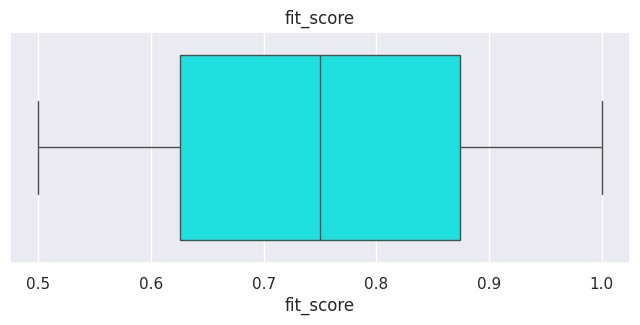

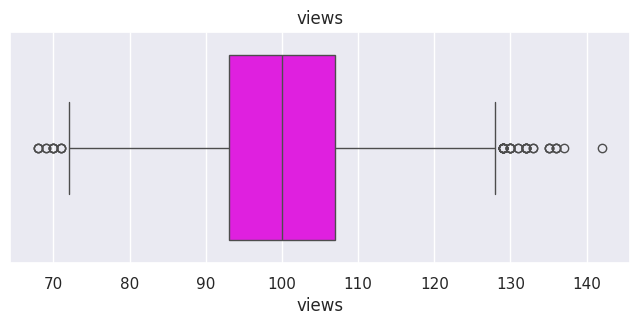

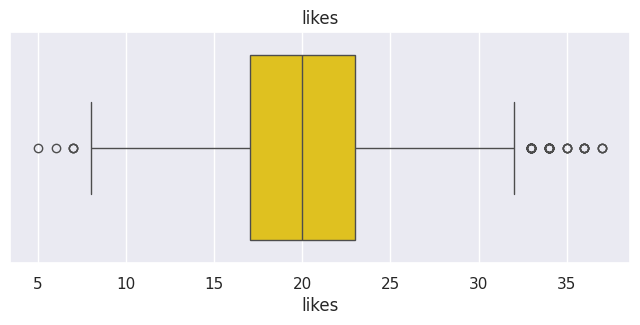

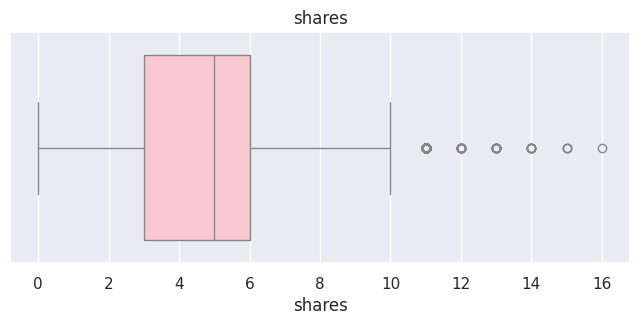

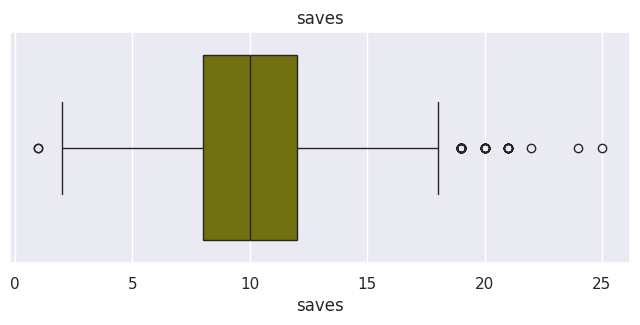

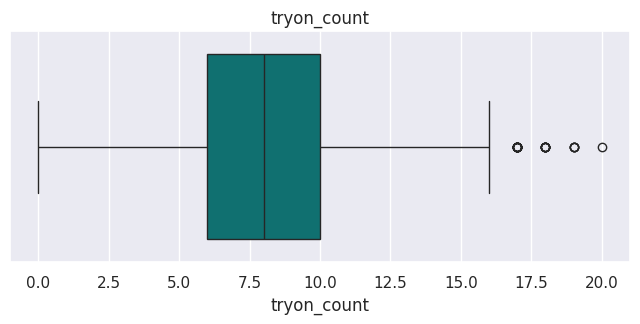

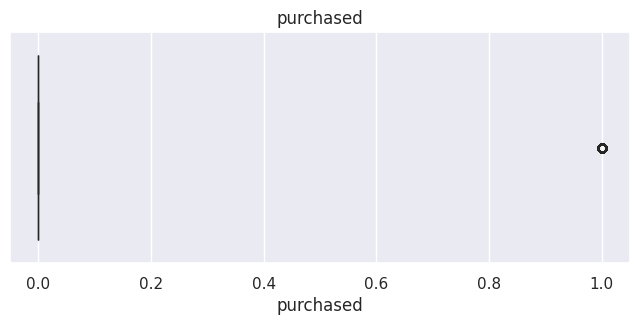

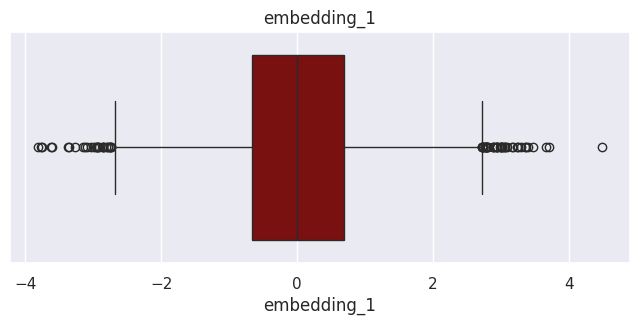

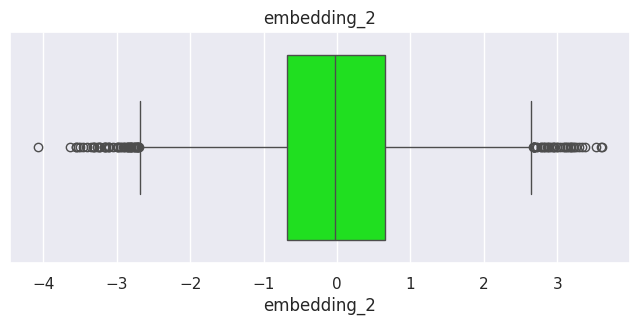

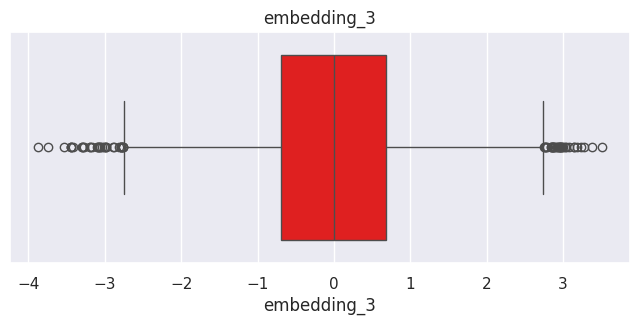

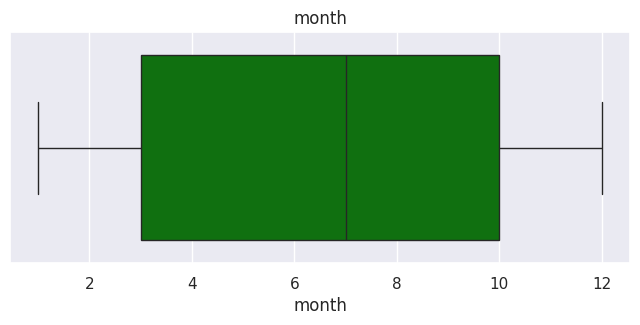

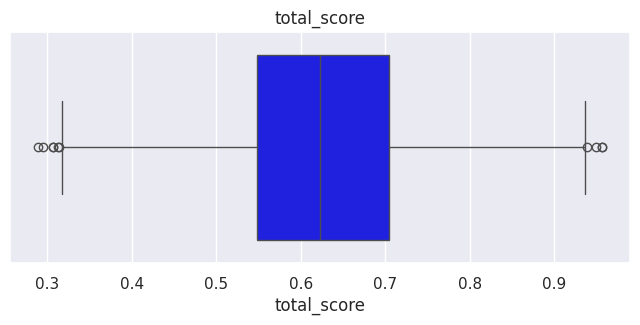

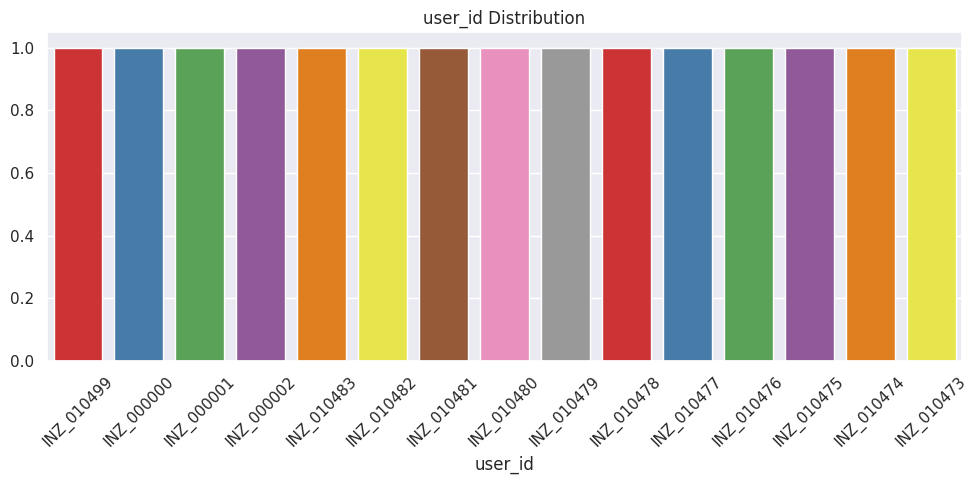

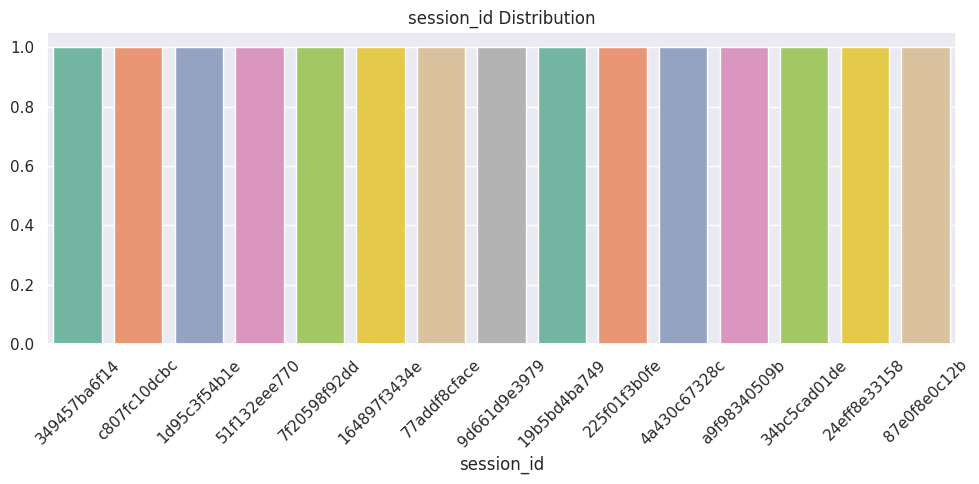

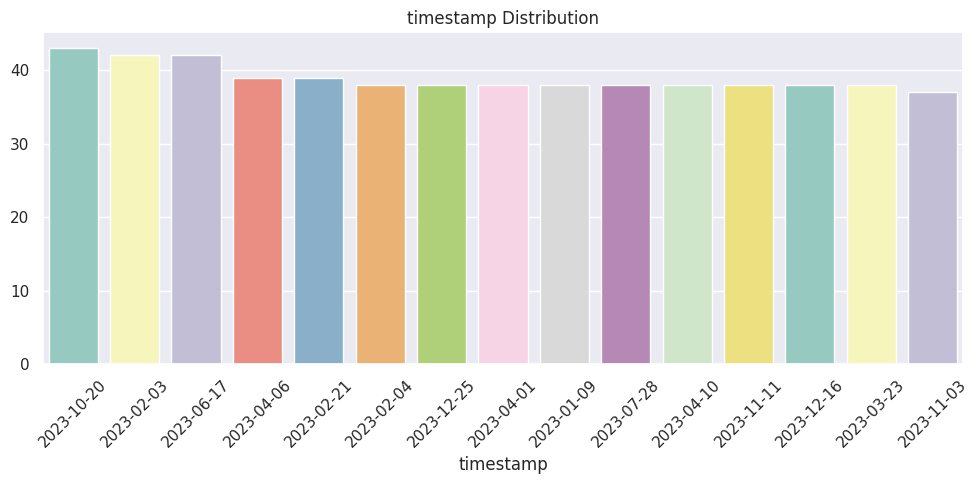

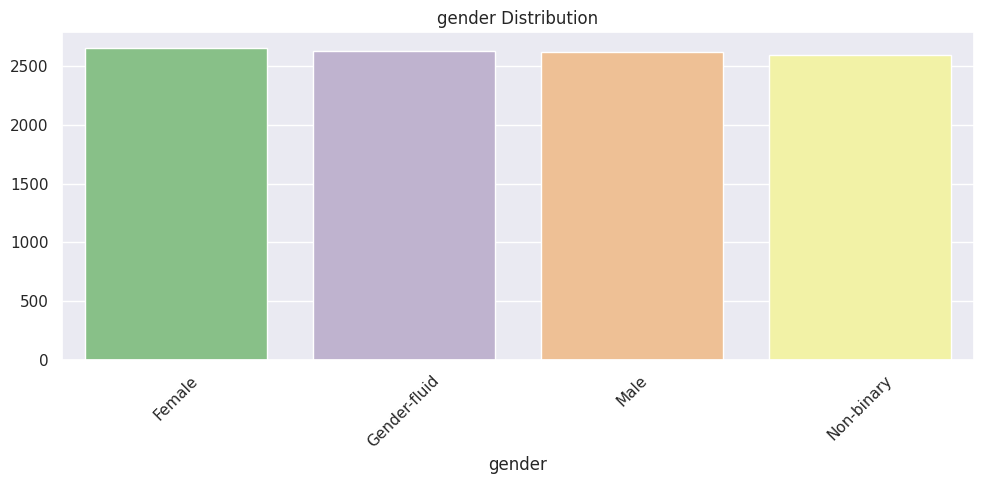

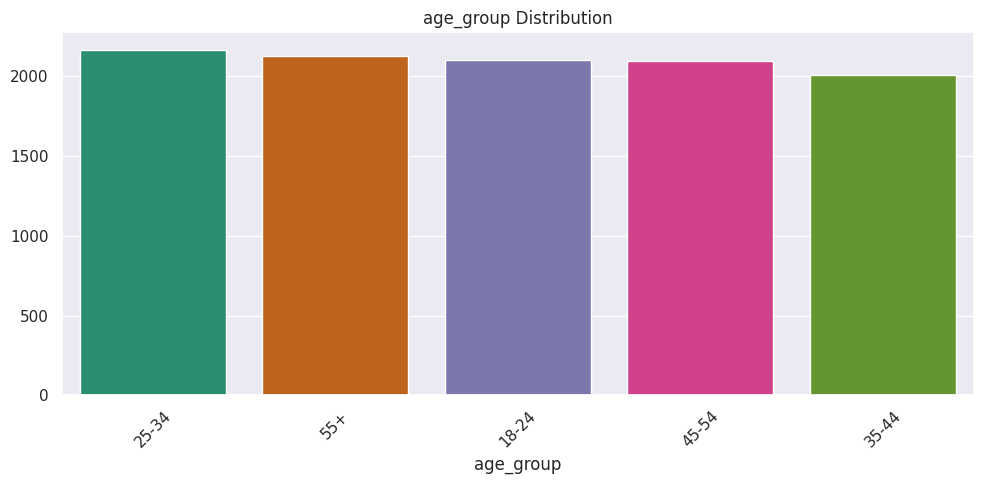

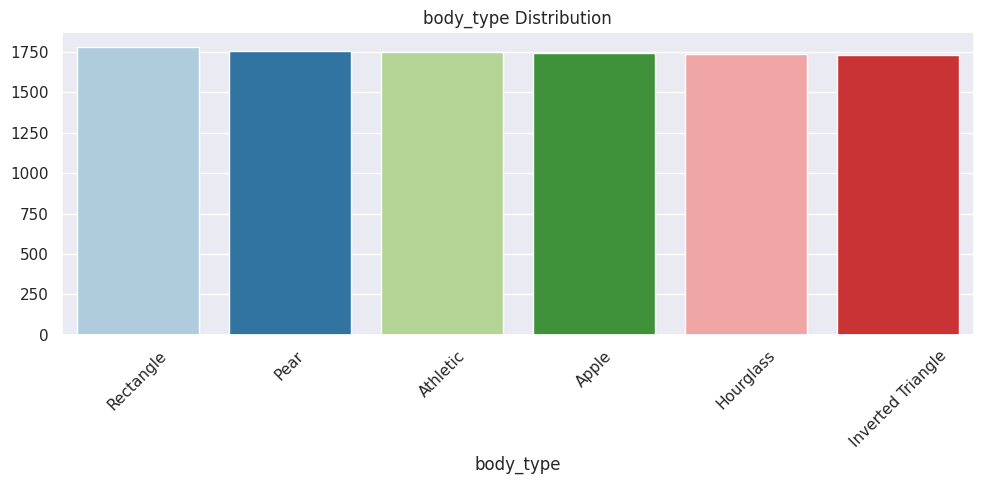

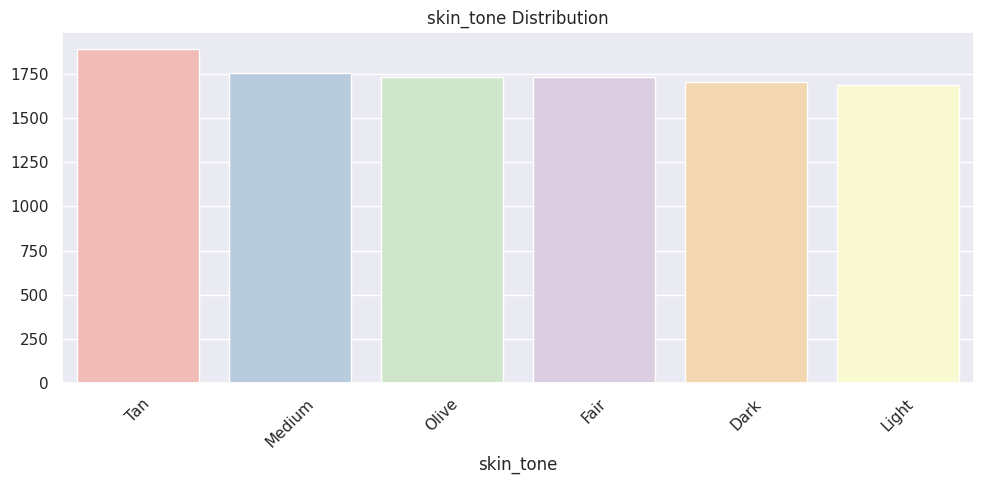

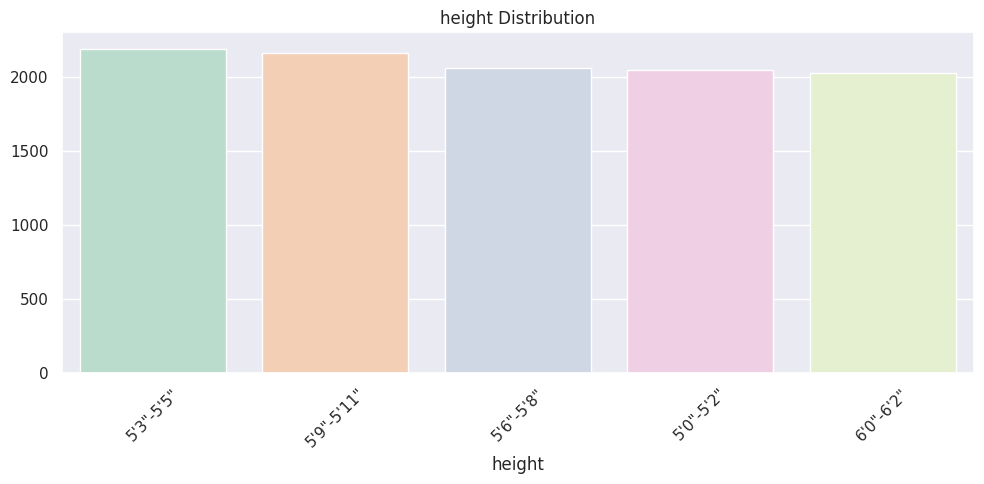

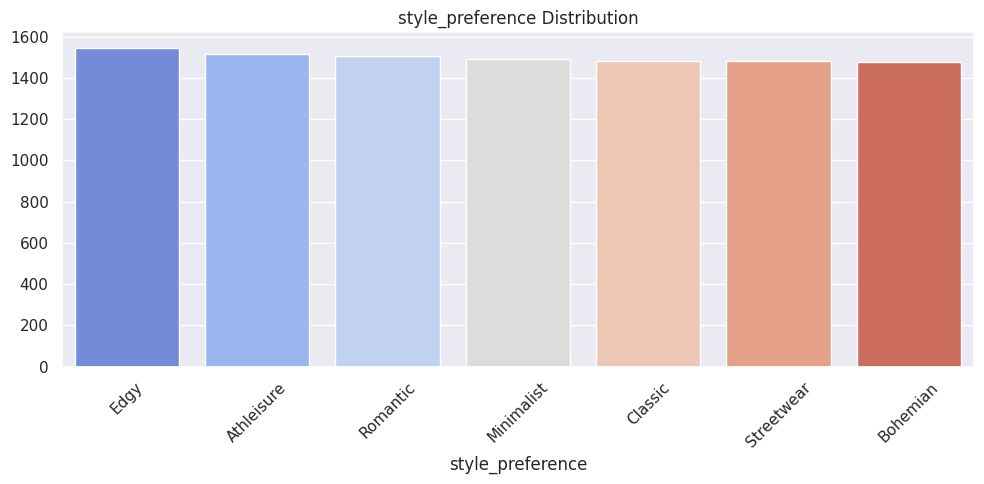

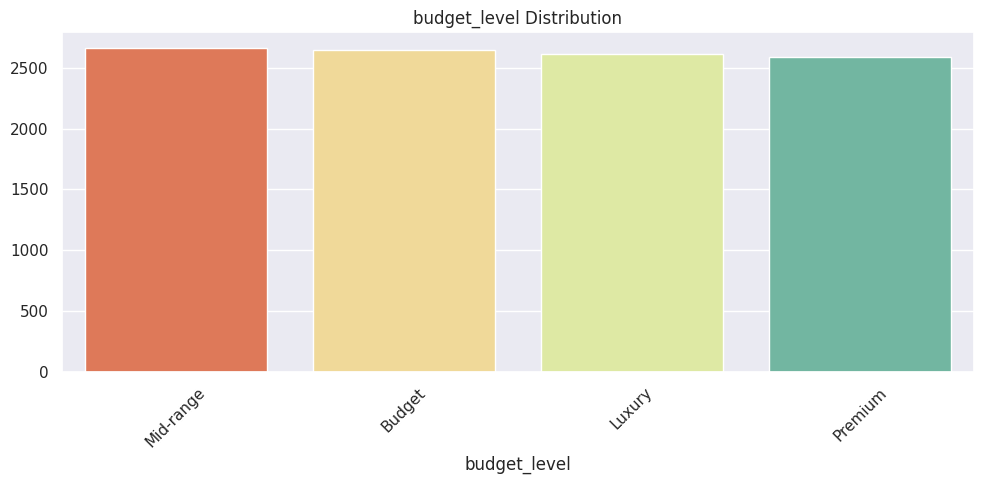

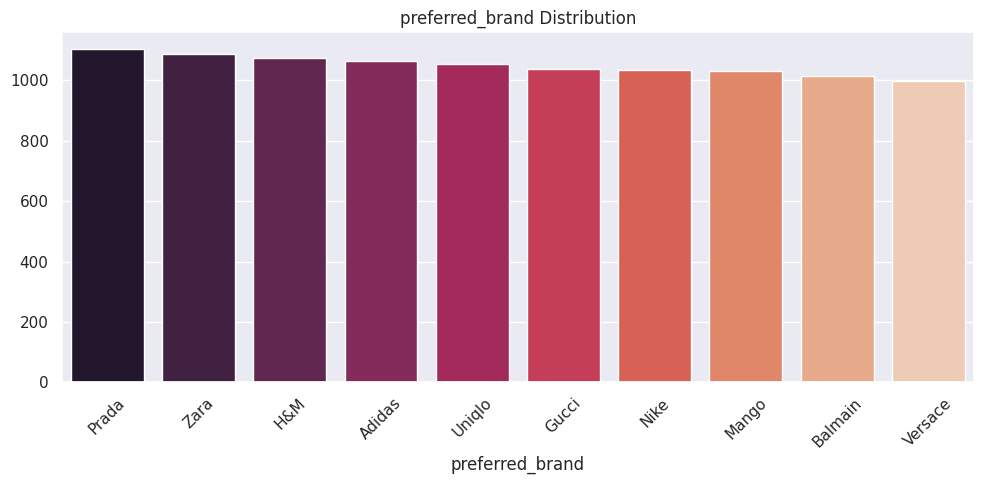

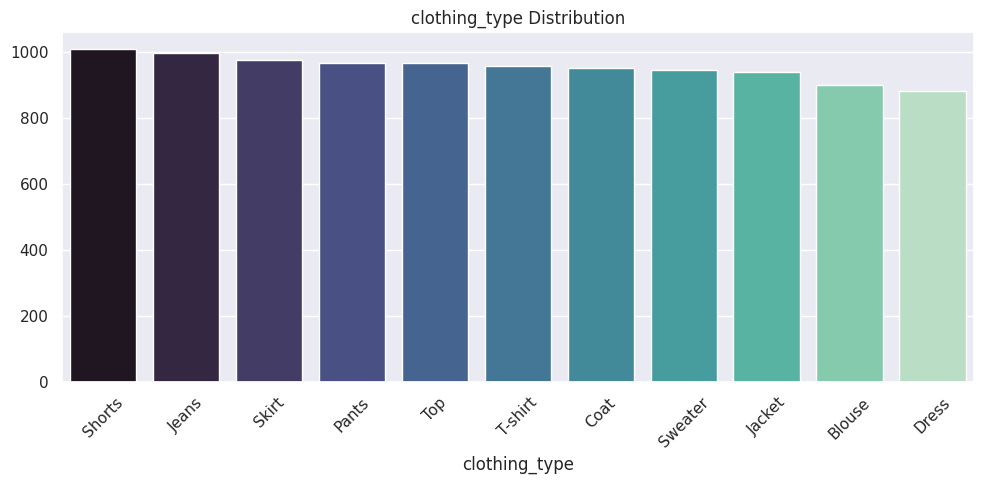

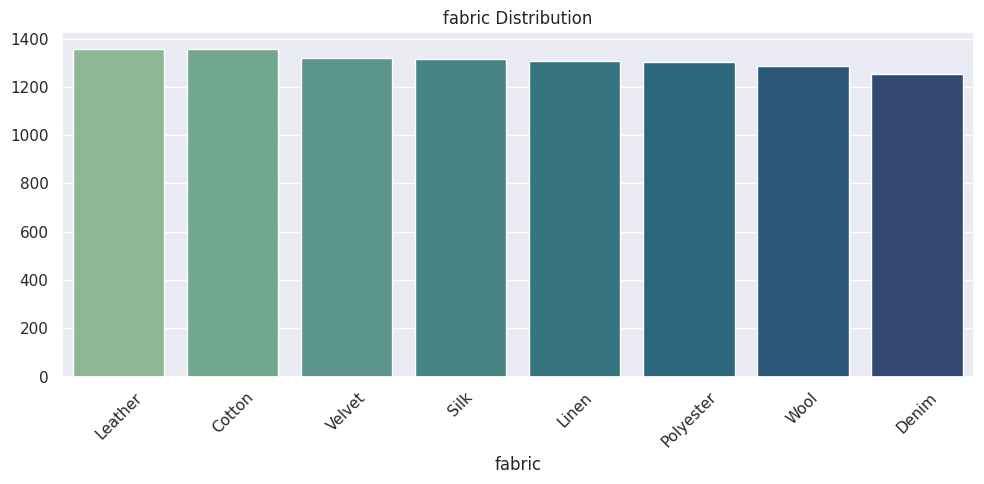

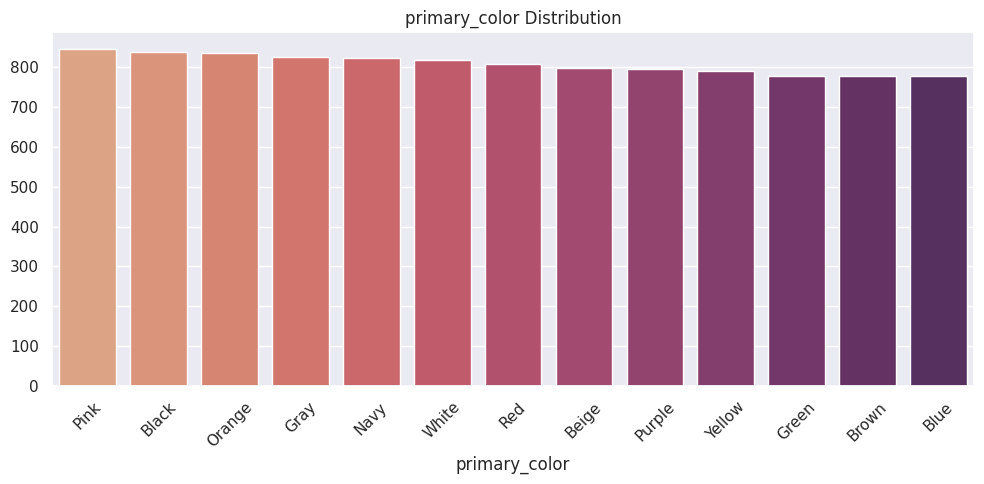

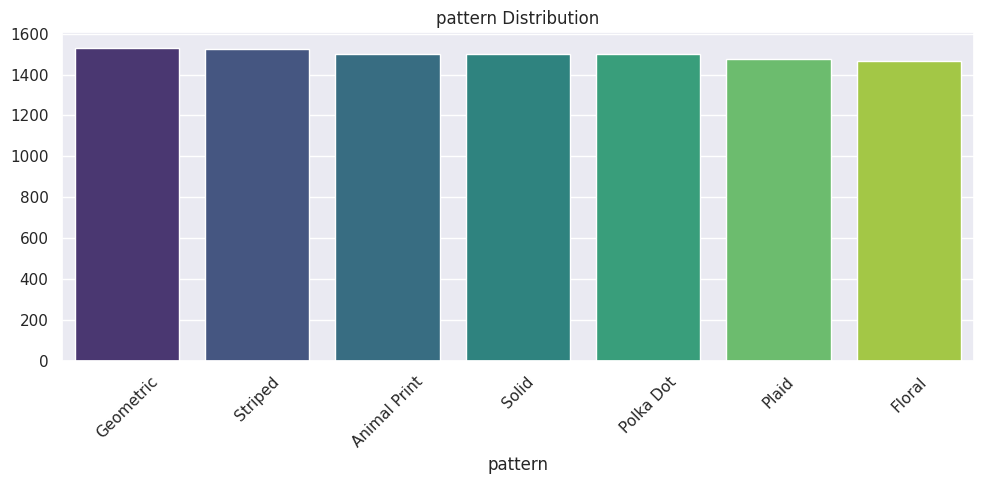

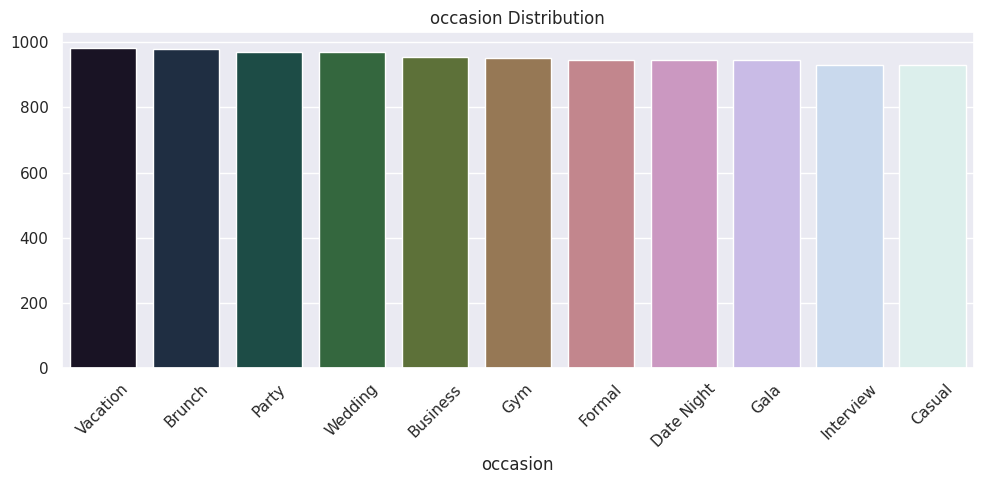

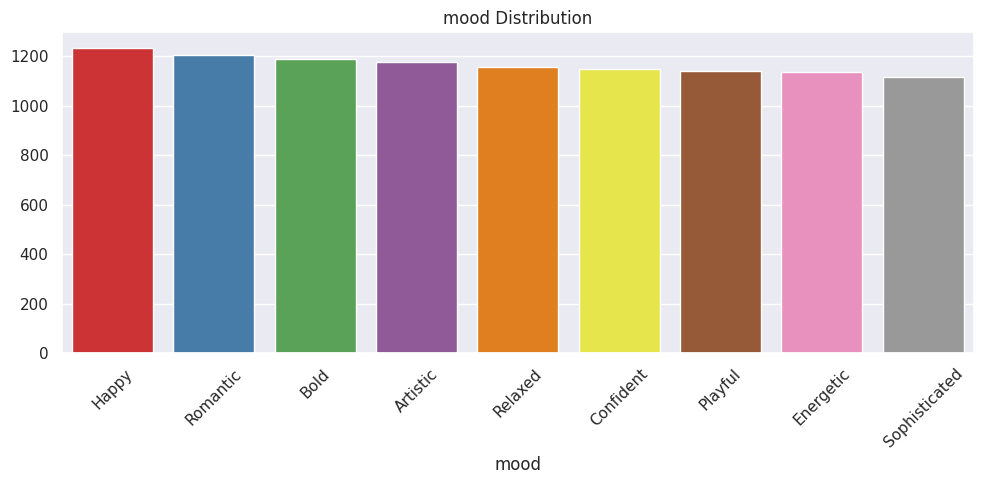

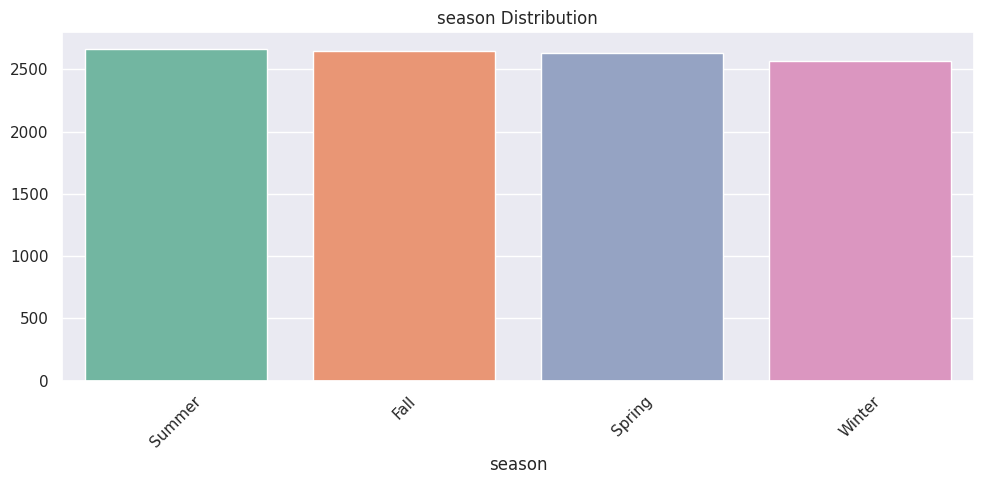

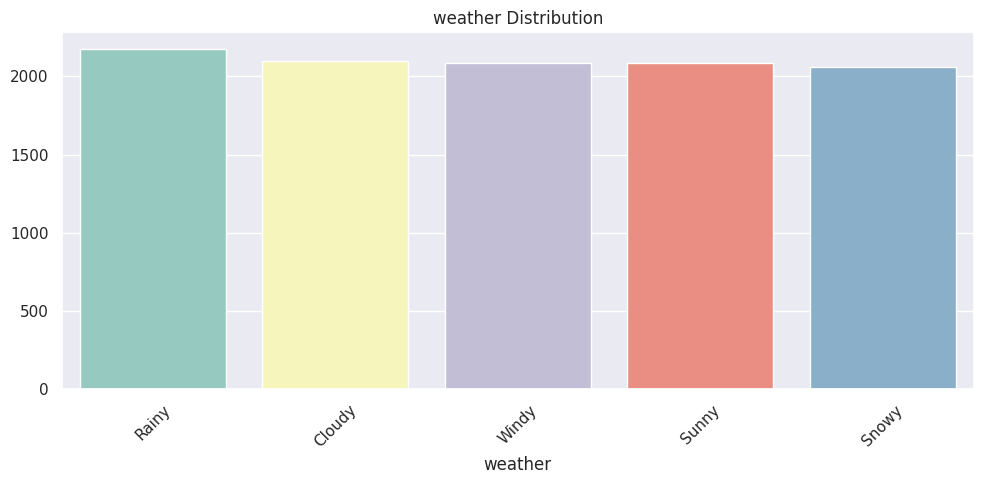

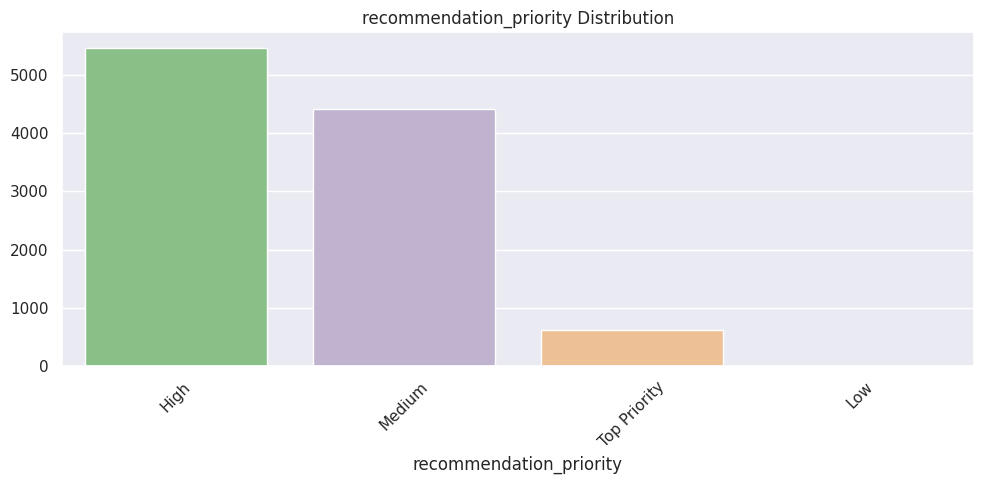

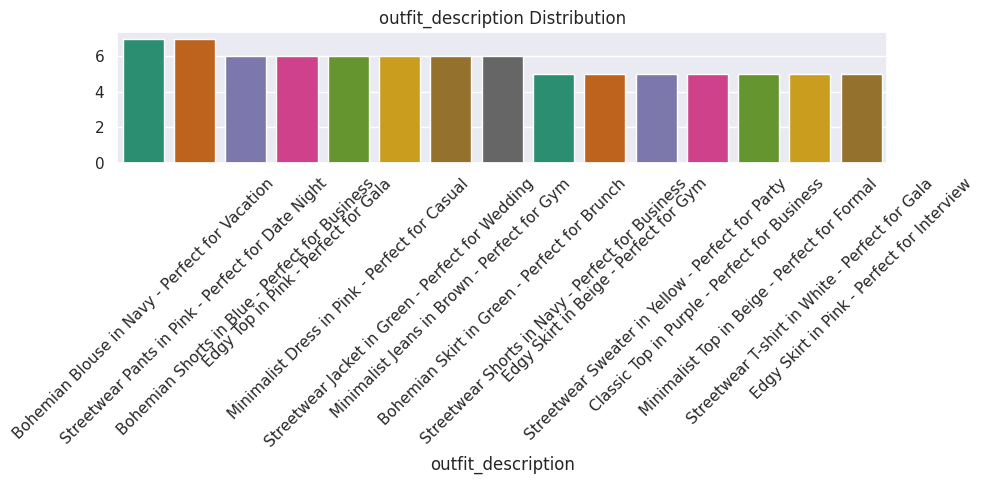

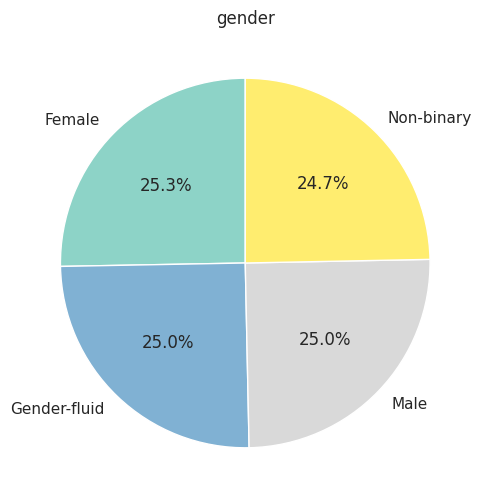

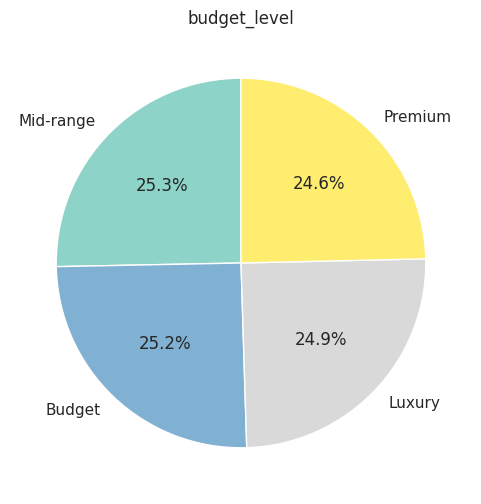

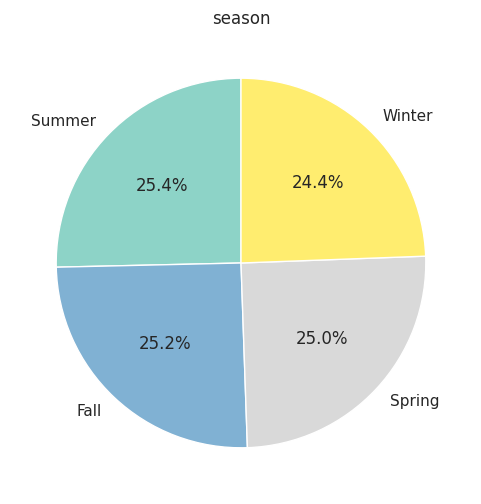

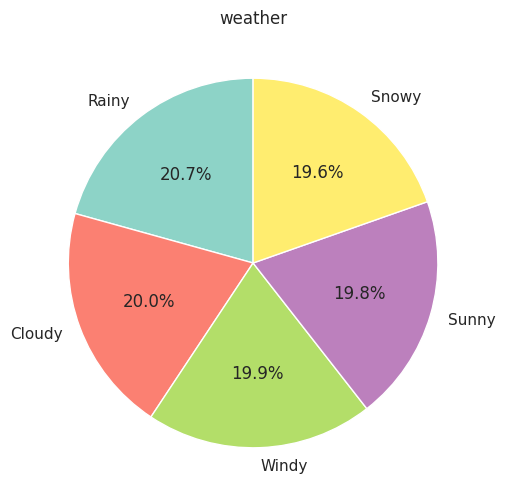

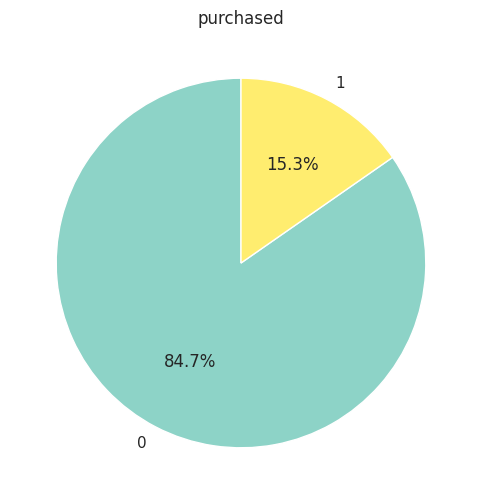

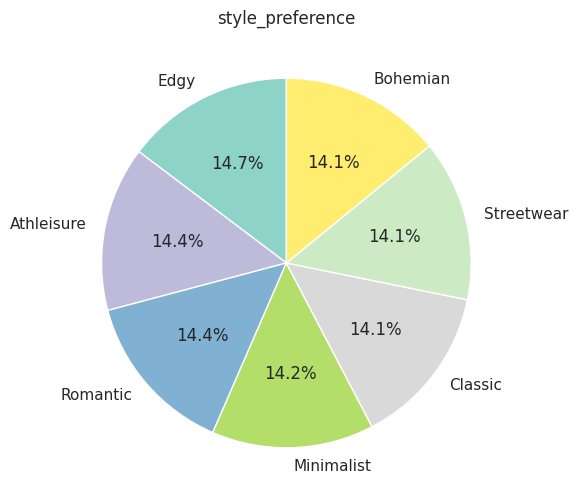

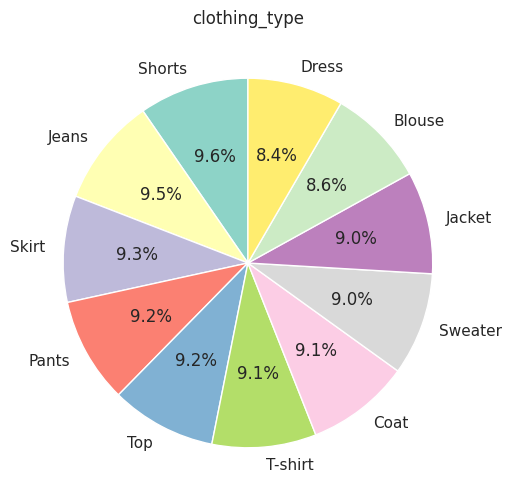

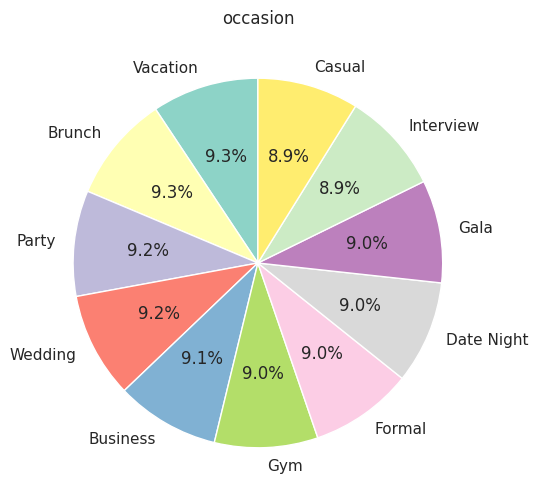

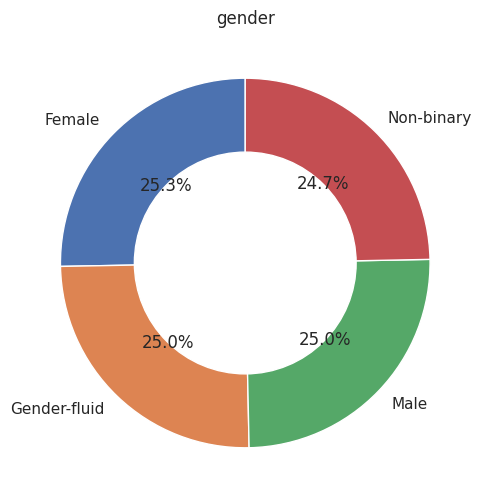

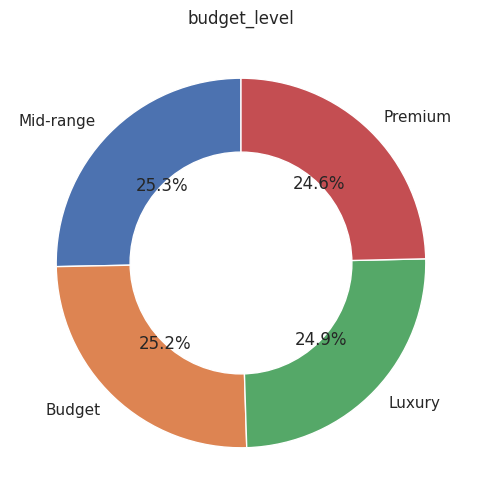

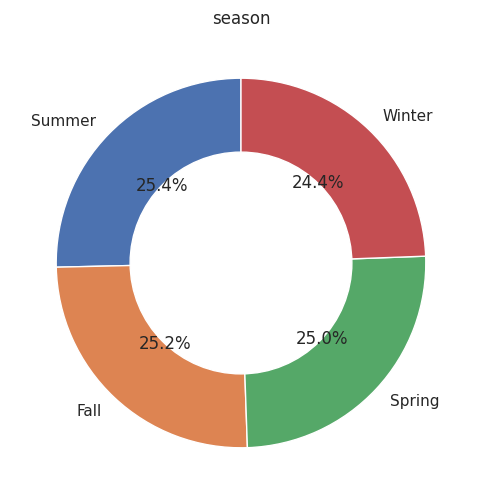

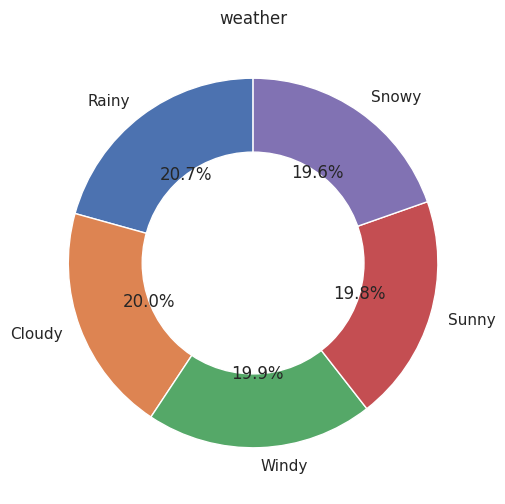

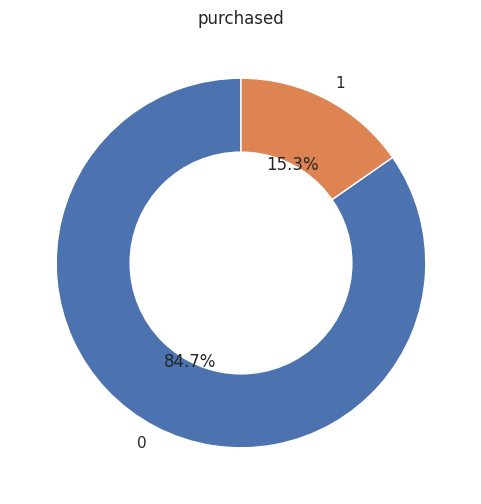

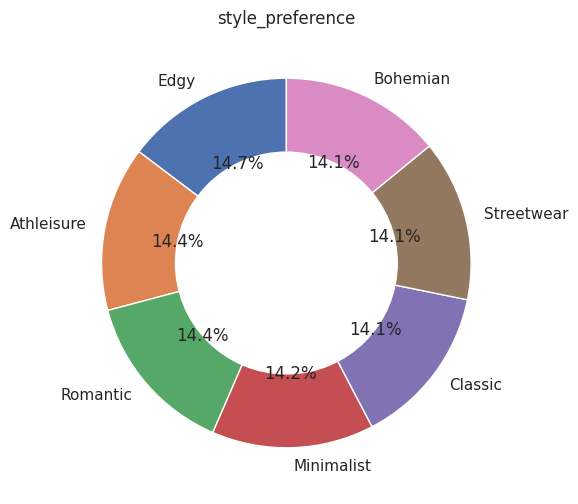

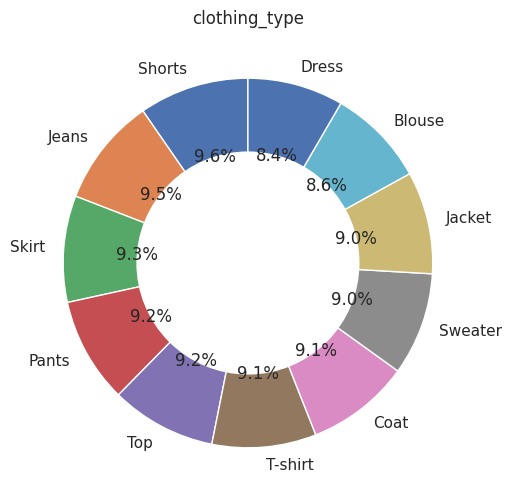

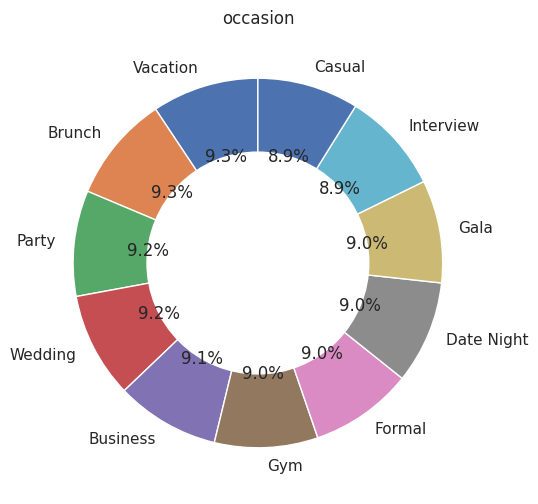

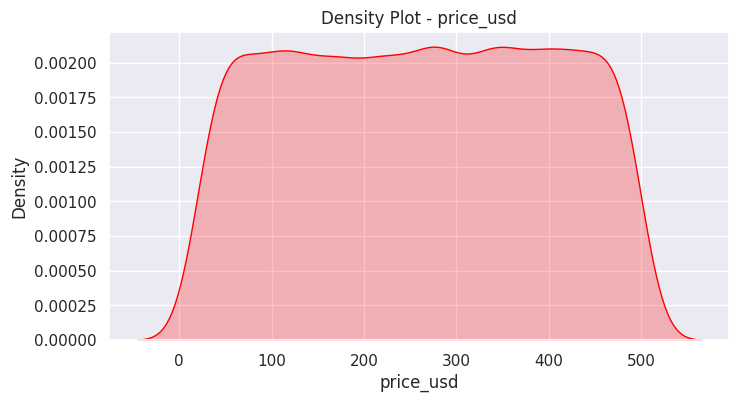

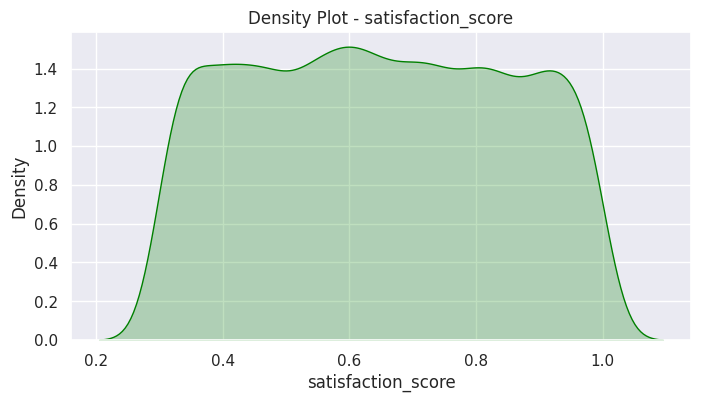

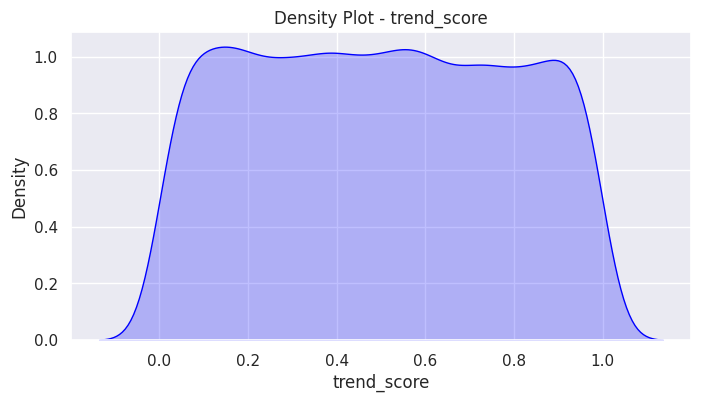

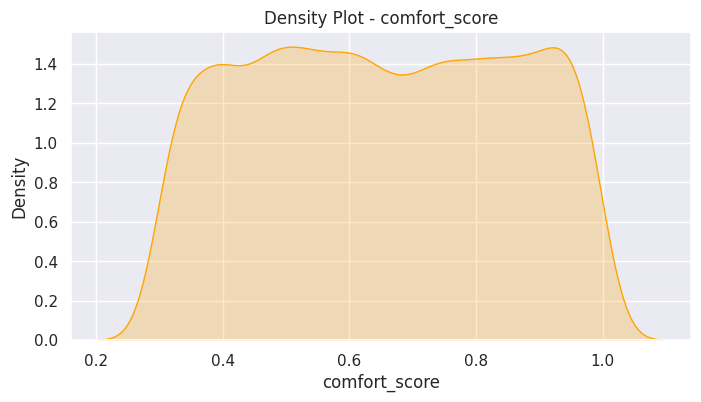

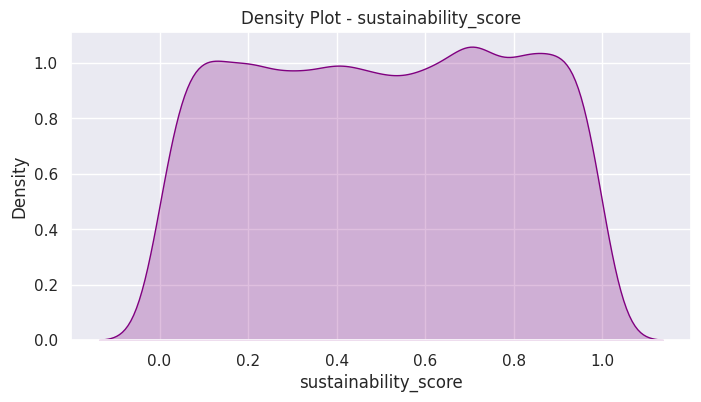

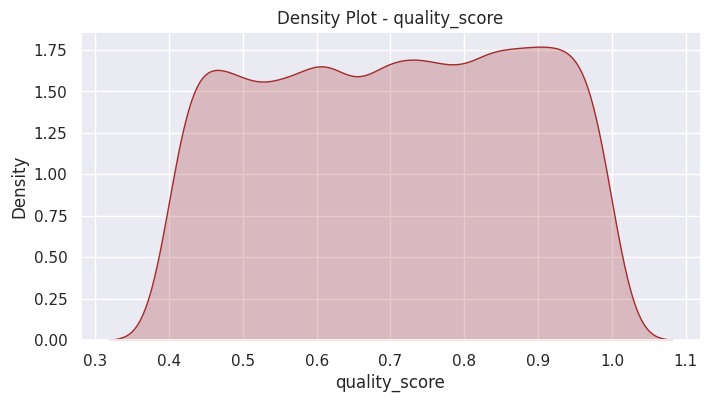

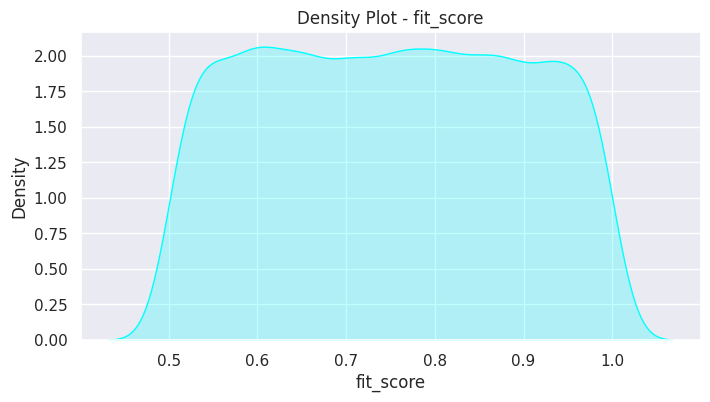

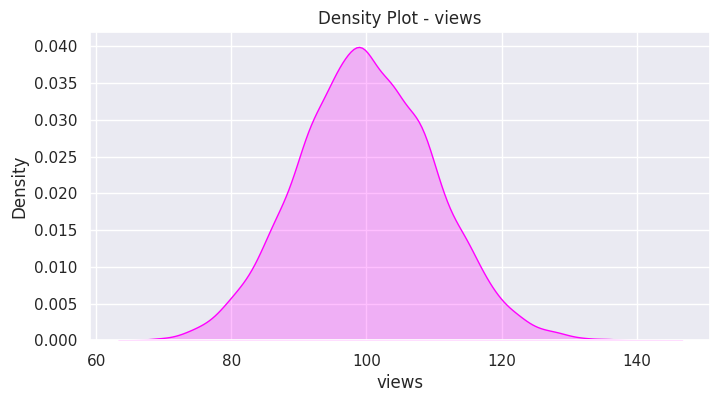

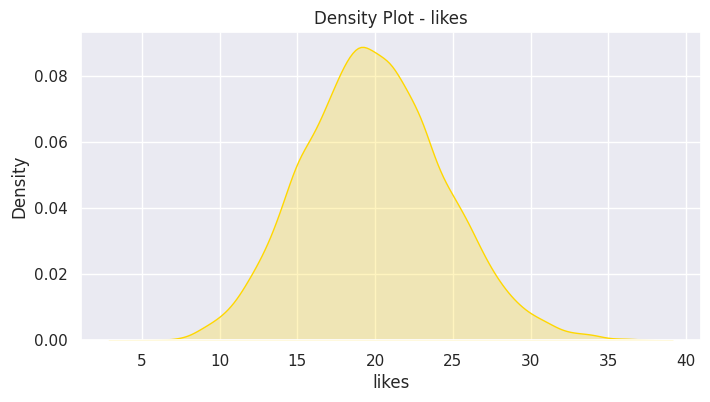

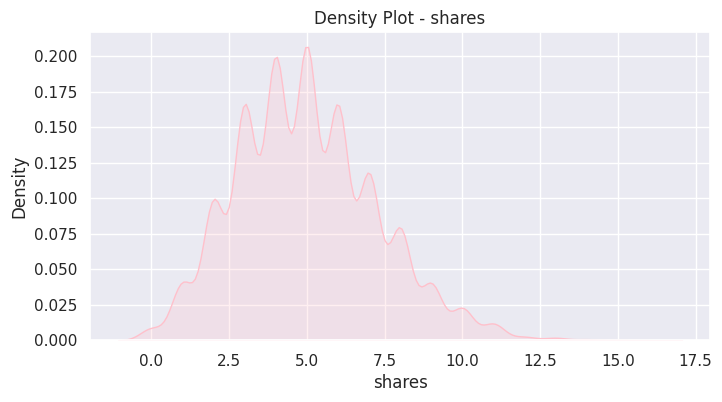

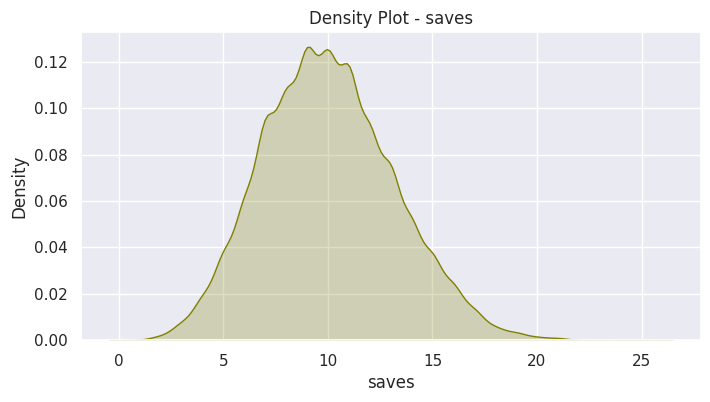

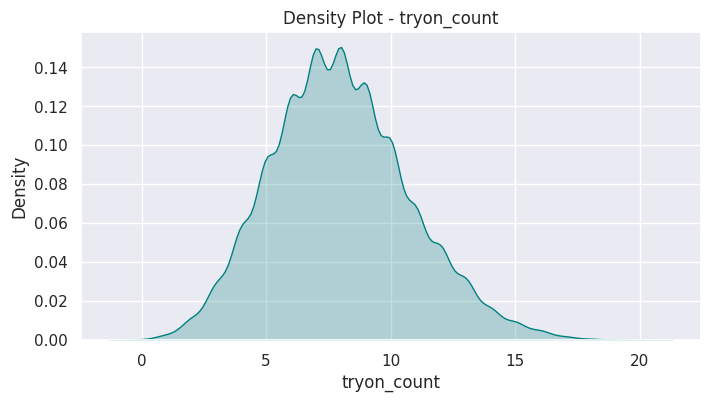

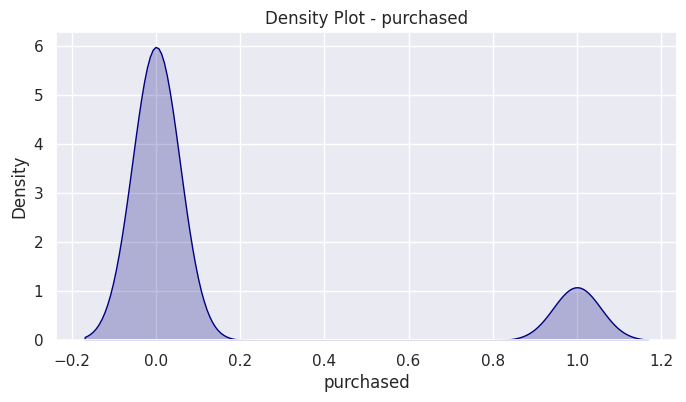

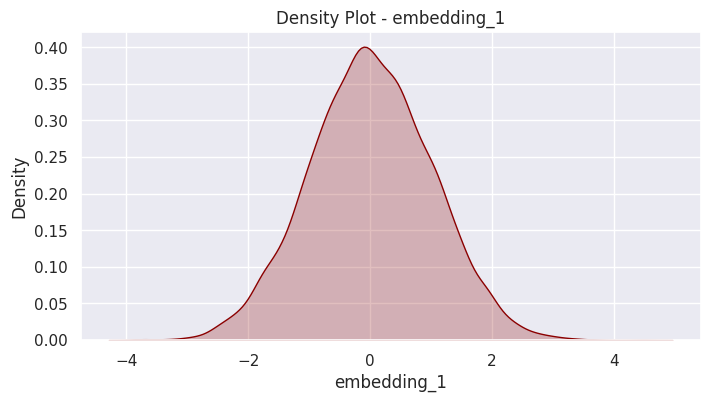

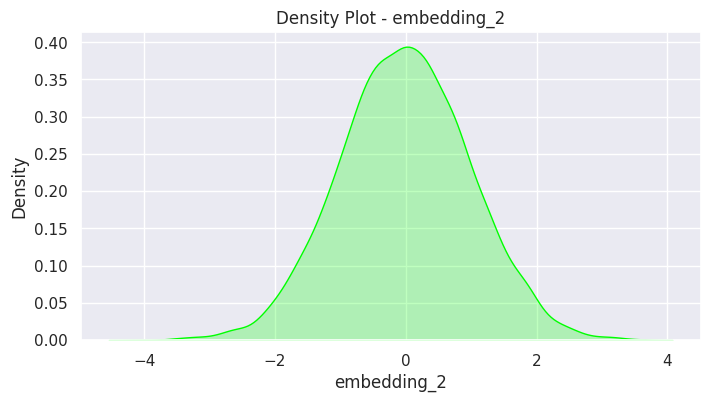

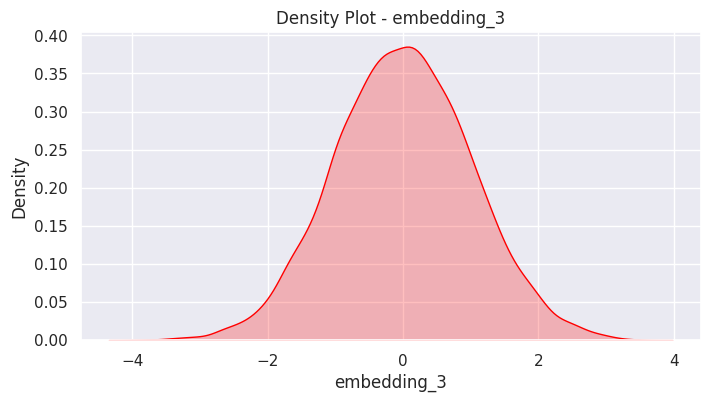

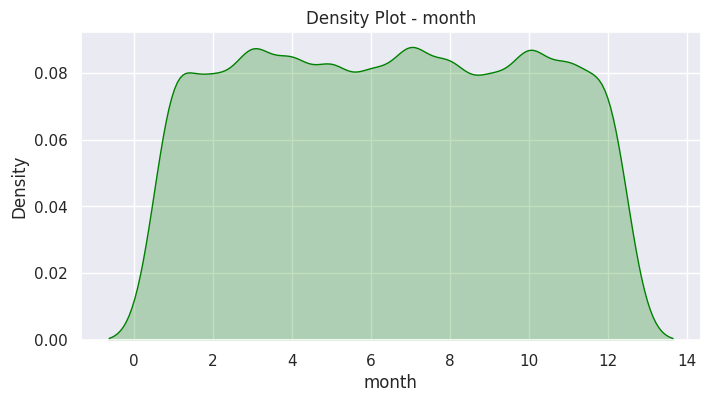

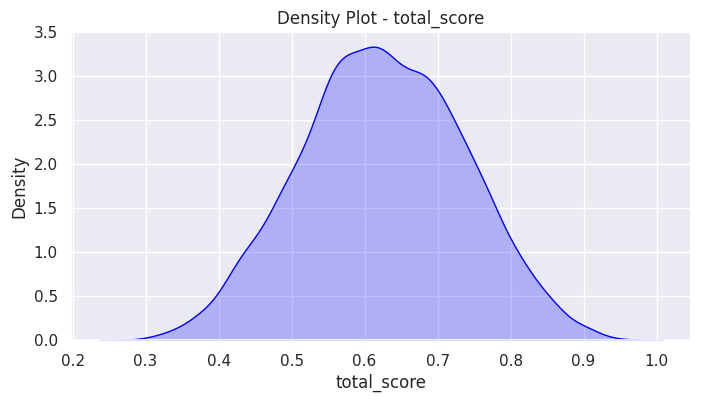

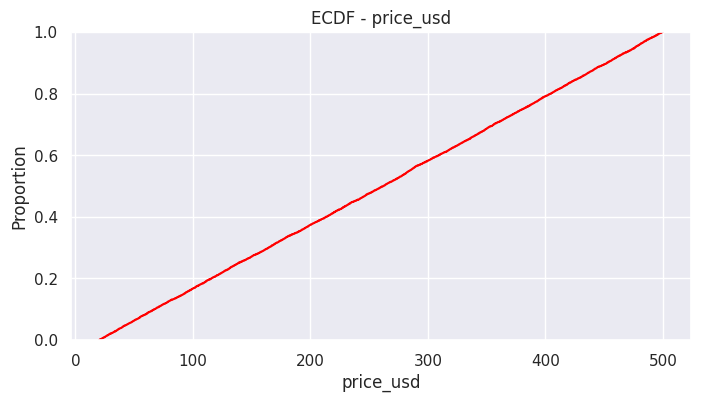

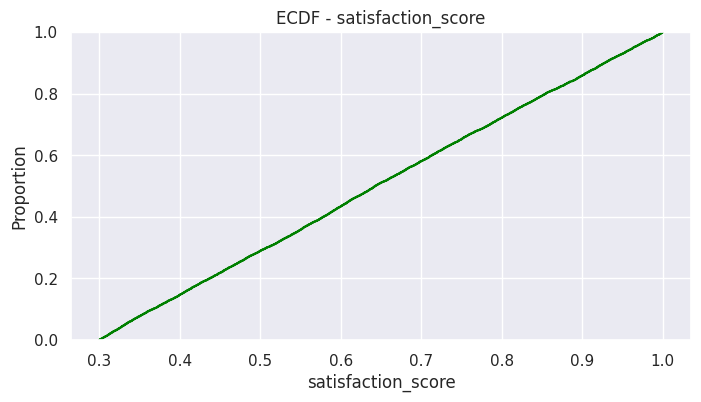

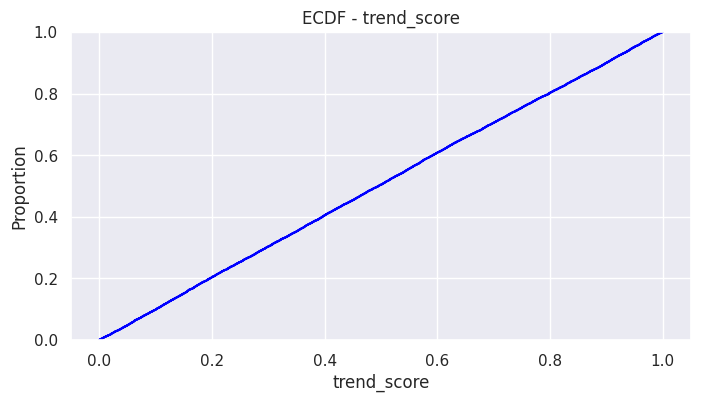

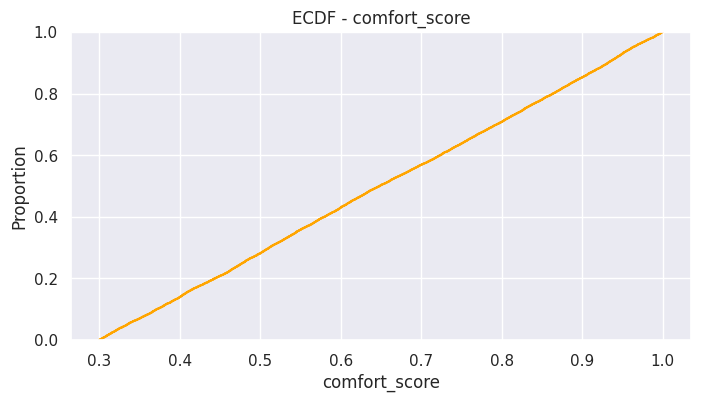

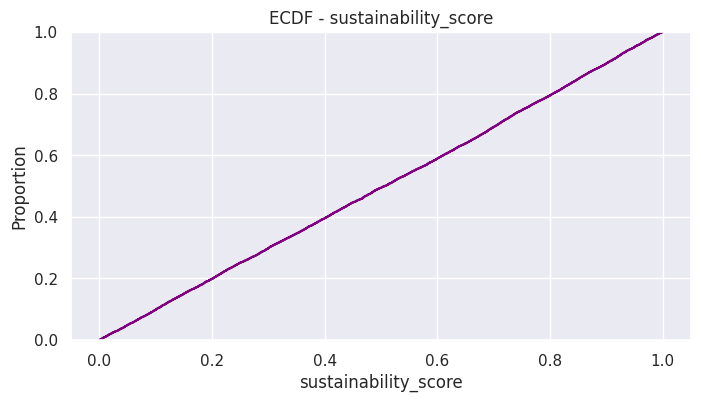

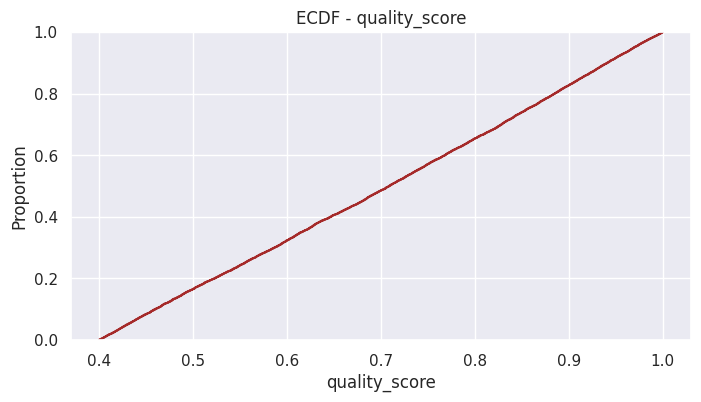

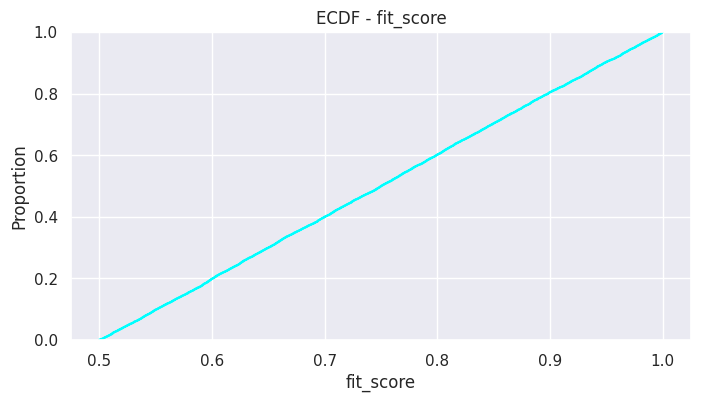

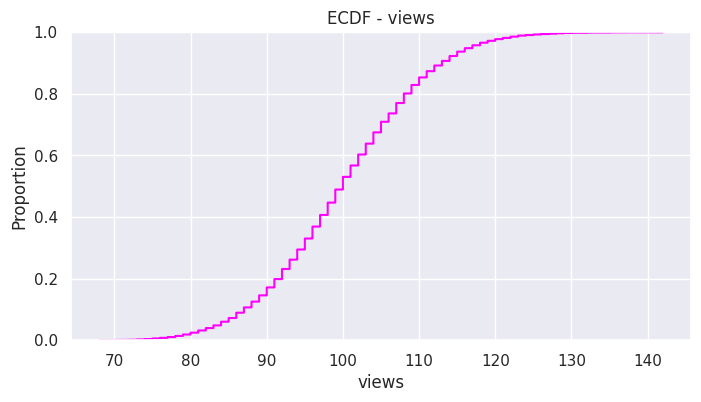

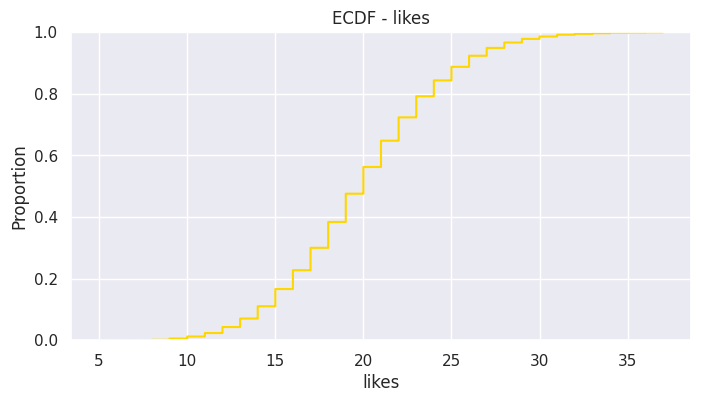

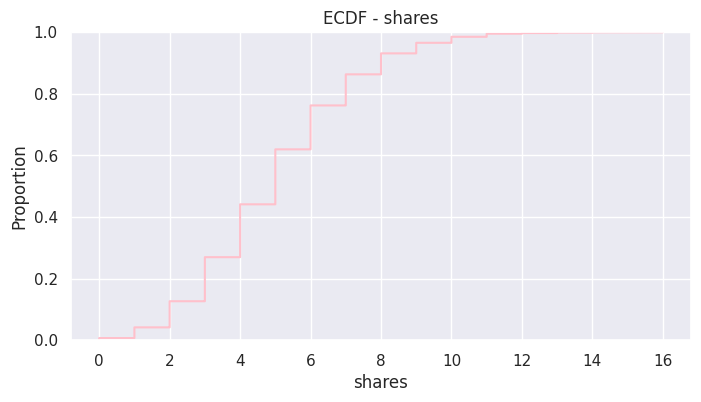

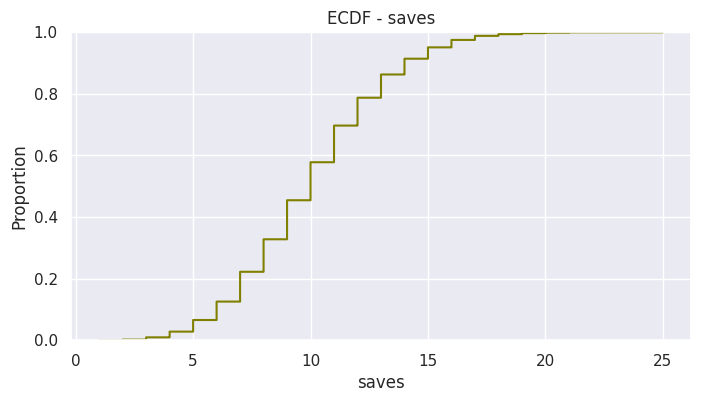

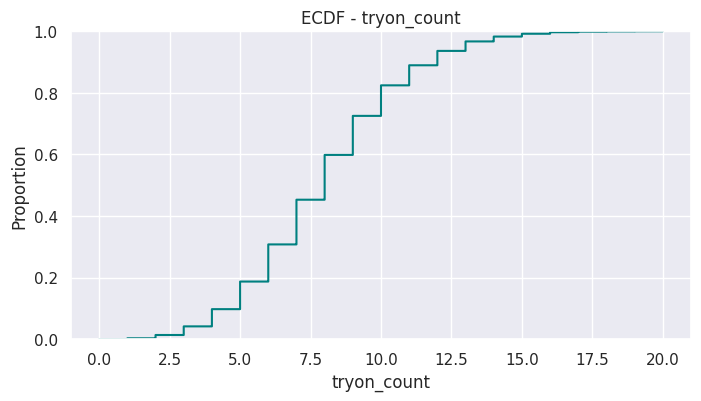

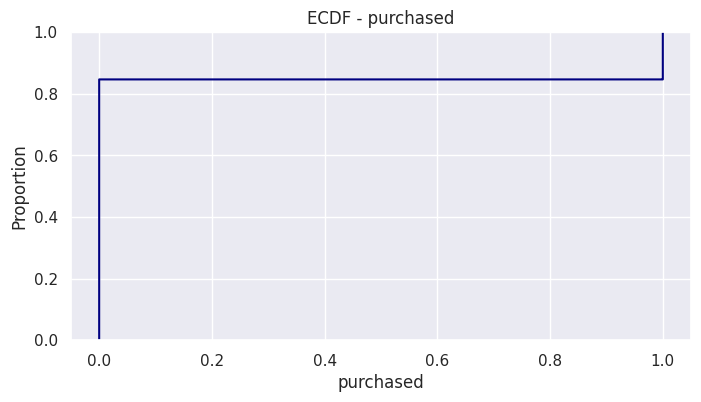

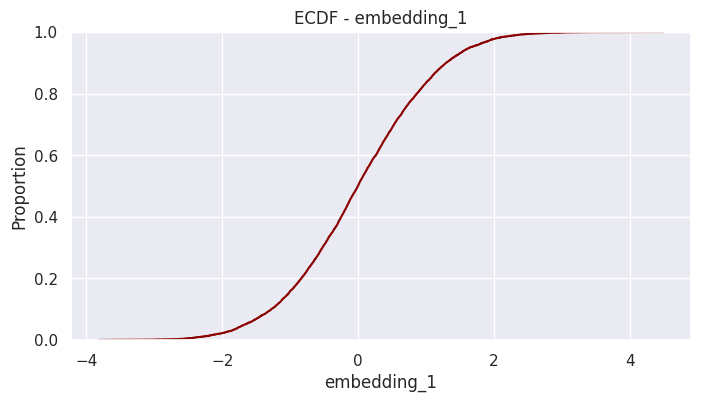

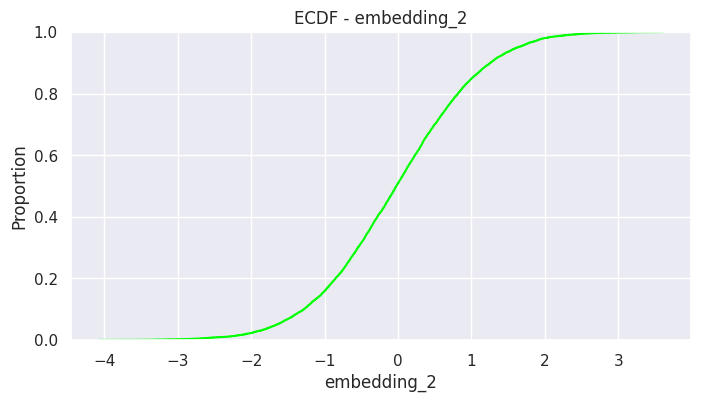

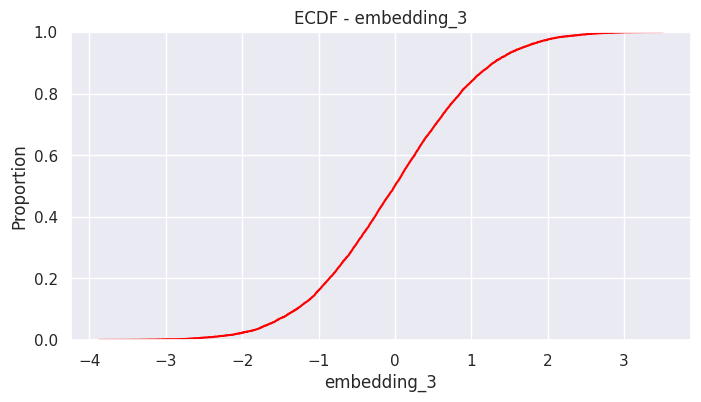

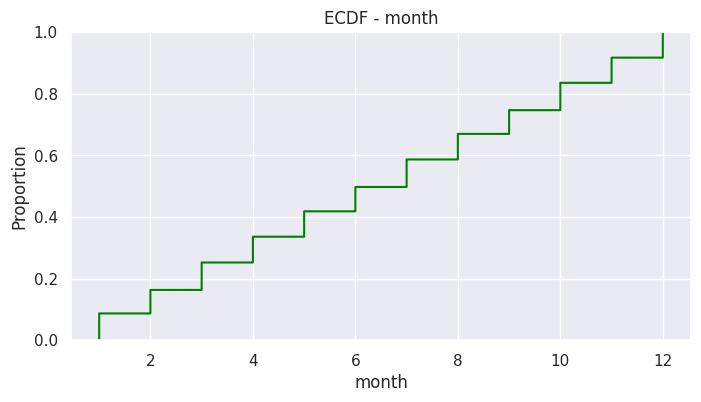

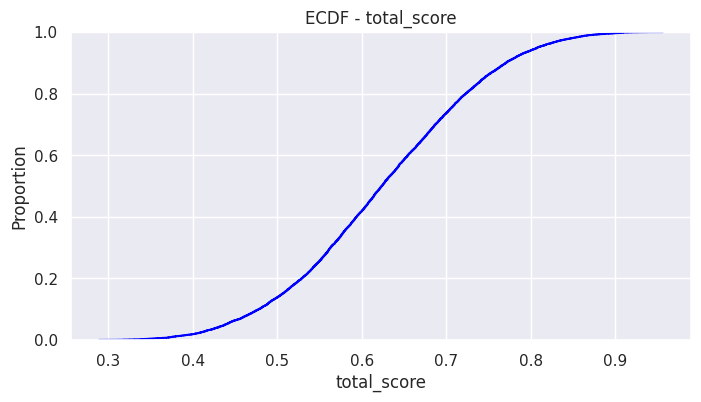

PART 1 COMPLETED


In [11]:
# ============================================================
# COMPLETE EDA OF FASHION RECOMMENDATION DATASET
# PART - 1
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1)

data = df.copy()

# ============================================================
# BASIC INFORMATION
# ============================================================

print("="*70)
print("Dataset Shape")
print(data.shape)

print("="*70)
print("First Five Rows")
print(data.head())

print("="*70)
print("Information")
print(data.info())

print("="*70)
print("Description")
print(data.describe(include="all"))

print("="*70)
print("Missing Values")
print(data.isnull().sum())

# ============================================================
# MISSING VALUE HEATMAP
# ============================================================

plt.figure(figsize=(16,6))

sns.heatmap(
    data.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Value Heatmap",fontsize=18)

plt.show()

# ============================================================
# NUMERICAL FEATURES
# ============================================================

num_cols=data.select_dtypes(include=np.number).columns

print(num_cols)

# ============================================================
# CATEGORICAL FEATURES
# ============================================================

cat_cols=data.select_dtypes(include="object").columns

print(cat_cols)

# ============================================================
# HISTOGRAM OF ALL NUMERIC FEATURES
# ============================================================

colors=[
"red","green","blue","orange","purple",
"brown","cyan","magenta","gold","pink",
"olive","teal","navy","darkred","lime"
]

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.histplot(
        data[col],
        bins=30,
        kde=True,
        color=colors[i%len(colors)]
    )

    plt.title(col,fontsize=15)

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

# ============================================================
# BOXPLOT OF EVERY NUMERIC FEATURE
# ============================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=data[col],
        color=colors[i%len(colors)]
    )

    plt.title(col)

    plt.show()

# ============================================================
# COUNTPLOT OF EVERY CATEGORICAL FEATURE
# ============================================================

palettes=[
"Set1",
"Set2",
"Set3",
"Accent",
"Dark2",
"Paired",
"Pastel1",
"Pastel2",
"coolwarm",
"Spectral",
"rocket",
"mako",
"crest",
"flare",
"viridis",
"cubehelix"
]

for i,col in enumerate(cat_cols):

    plt.figure(figsize=(10,5))

    vc=data[col].value_counts().head(15)

    sns.barplot(
        x=vc.index,
        y=vc.values,
        palette=palettes[i%len(palettes)]
    )

    plt.xticks(rotation=45)

    plt.title(col+" Distribution")

    plt.tight_layout()

    plt.show()

# ============================================================
# PIE CHARTS
# ============================================================

important_cols=[
"gender",
"budget_level",
"season",
"weather",
"purchased",
"style_preference",
"clothing_type",
"occasion"
]

for col in important_cols:

    if col in data.columns:

        plt.figure(figsize=(6,6))

        data[col].value_counts().plot(
            kind="pie",
            autopct="%1.1f%%",
            startangle=90,
            cmap="Set3"
        )

        plt.ylabel("")

        plt.title(col)

        plt.show()

# ============================================================
# DONUT CHARTS
# ============================================================

for col in important_cols:

    if col in data.columns:

        counts=data[col].value_counts()

        fig,ax=plt.subplots(figsize=(6,6))

        ax.pie(
            counts,
            labels=counts.index,
            autopct="%1.1f%%",
            startangle=90
        )

        centre_circle=plt.Circle((0,0),0.60,fc="white")

        fig.gca().add_artist(centre_circle)

        plt.title(col)

        plt.show()

# ============================================================
# KERNEL DENSITY PLOTS
# ============================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data[col],
        fill=True,
        color=colors[i%len(colors)]
    )

    plt.title("Density Plot - "+col)

    plt.show()

# ============================================================
# CUMULATIVE DISTRIBUTION
# ============================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.ecdfplot(
        data[col],
        color=colors[i%len(colors)]
    )

    plt.title("ECDF - "+col)

    plt.show()

print("="*70)
print("PART 1 COMPLETED")
print("="*70)

## Features Engineering

## Features Engineering

In [12]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    label_binarize
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ============================================================
# MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

# ============================================================
# DATASET
# ============================================================

data = df.copy()

# ============================================================
# REMOVE USELESS COLUMNS
# ============================================================

drop_columns = [
    "user_id",
    "session_id",
    "timestamp",
    "outfit_description"
]

for col in drop_columns:
    if col in data.columns:
        data.drop(col, axis=1, inplace=True)

# ============================================================
# TARGET
# ============================================================

target = "recommendation_priority"

X = data.drop(target, axis=1)

y = data[target]

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# LABEL ENCODE TARGET
# ============================================================

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)

y_test = target_encoder.transform(y_test)

# ============================================================
# ENCODE CATEGORICAL FEATURES
# ============================================================

categorical_columns = X_train.select_dtypes(include="object").columns

encoders = {}

for column in categorical_columns:

    encoder = LabelEncoder()

    X_train[column] = encoder.fit_transform(
        X_train[column].astype(str)
    )

    X_test[column] = X_test[column].astype(str)

    mapping = dict(
        zip(
            encoder.classes_,
            encoder.transform(encoder.classes_)
        )
    )

    encoders[column] = encoder

    X_test[column] = X_test[column].apply(
        lambda x:
        encoder.transform([x])[0]
        if x in encoder.classes_
        else -1
    )

# ============================================================
# MISSING VALUES
# ============================================================

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(

    imputer.fit_transform(X_train),

    columns=X_train.columns

)

X_test = pd.DataFrame(

    imputer.transform(X_test),

    columns=X_test.columns

)

# ============================================================
# STANDARD SCALER
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# ============================================================
# MODELS
# ============================================================

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=5000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(random_state=42),

    "Extra Trees":
    ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ),

    "AdaBoost":
    AdaBoostClassifier(random_state=42),

    "KNN":
    KNeighborsClassifier(),

    "SVM":
    SVC(
        probability=True,
        random_state=42
    ),

    "Naive Bayes":
    GaussianNB()

}

# ============================================================
# TRAIN MODELS
# ============================================================

results = []

trained_models = {}

for model_name, model in models.items():

    print("="*80)

    print(model_name)

    print("="*80)

    model.fit(X_train, y_train)

    trained_models[model_name] = model

    prediction = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    print("Accuracy :", accuracy)

    print("Precision:", precision)

    print("Recall   :", recall)

    print("F1 Score :", f1)

    results.append(
        [
            model_name,
            accuracy,
            precision,
            recall,
            f1
        ]
    )

print("\nTraining Completed Successfully")

Logistic Regression
Accuracy : 0.9909523809523809
Precision: 0.9909718789944416
Recall   : 0.9909523809523809
F1 Score : 0.9908903687295846
Decision Tree
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Random Forest
Accuracy : 0.9995238095238095
Precision: 0.9995242451967064
Recall   : 0.9995238095238095
F1 Score : 0.9995229545435496
Gradient Boosting
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Extra Trees
Accuracy : 0.9595238095238096
Precision: 0.9613798862458656
Recall   : 0.9595238095238096
F1 Score : 0.9567572992952308
AdaBoost
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
KNN
Accuracy : 0.8161904761904762
Precision: 0.8252005770429732
Recall   : 0.8161904761904762
F1 Score : 0.8059280177614476
SVM
Accuracy : 0.9619047619047619
Precision: 0.962827171469026
Recall   : 0.9619047619047619
F1 Score : 0.9610794692353495
Naive Bayes
Accuracy : 0.9714285714285714
Precision: 0.9720101820033092
Recall   : 0.9714285714285714
F1 Score : 0.97160599741



Logistic Regression

Classification Report

              precision    recall  f1-score   support

        High       0.99      1.00      0.99      1092
      Medium       1.00      0.99      0.99       884
Top Priority       0.99      0.93      0.96       124

    accuracy                           0.99      2100
   macro avg       0.99      0.97      0.98      2100
weighted avg       0.99      0.99      0.99      2100



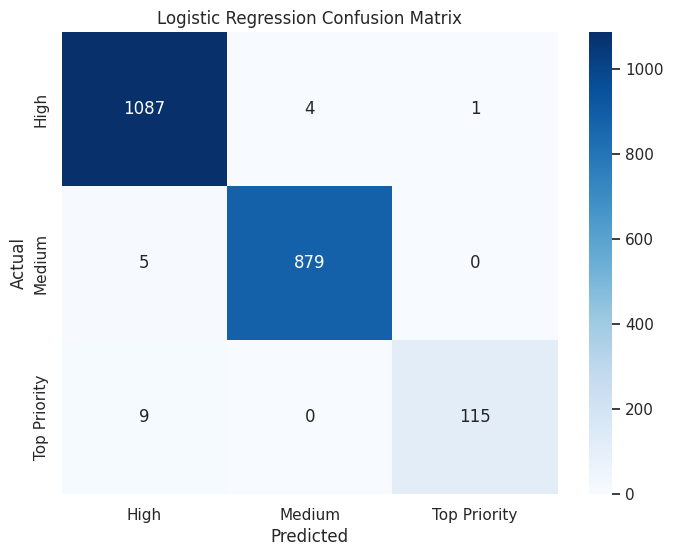

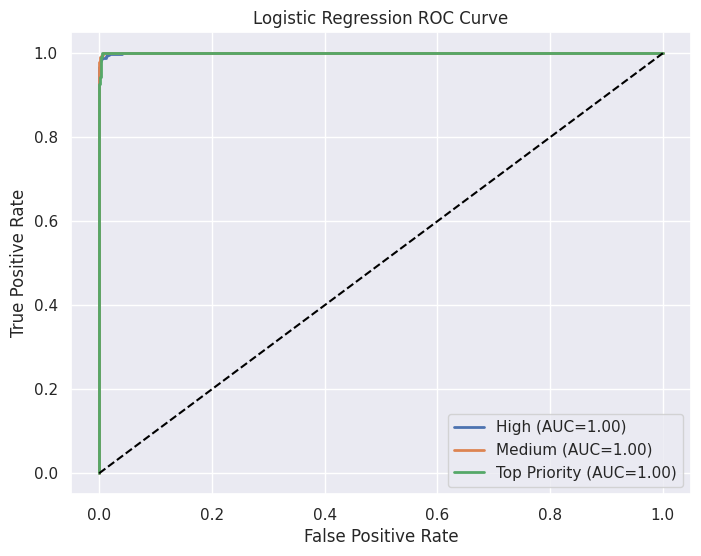



Decision Tree

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1092
      Medium       1.00      1.00      1.00       884
Top Priority       1.00      1.00      1.00       124

    accuracy                           1.00      2100
   macro avg       1.00      1.00      1.00      2100
weighted avg       1.00      1.00      1.00      2100



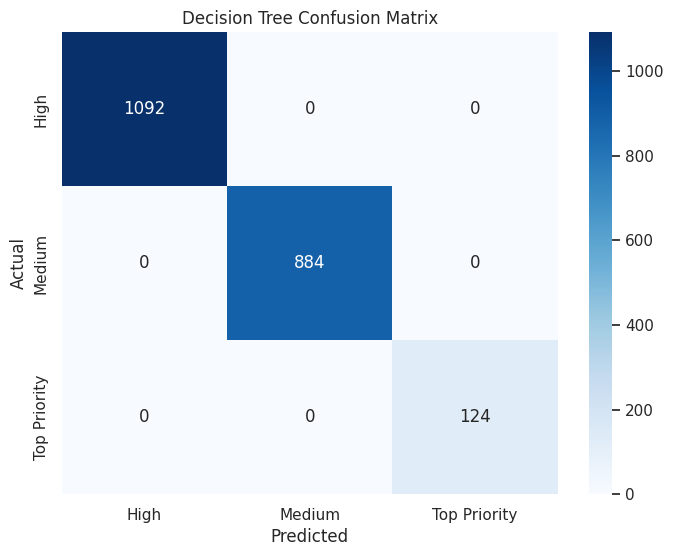

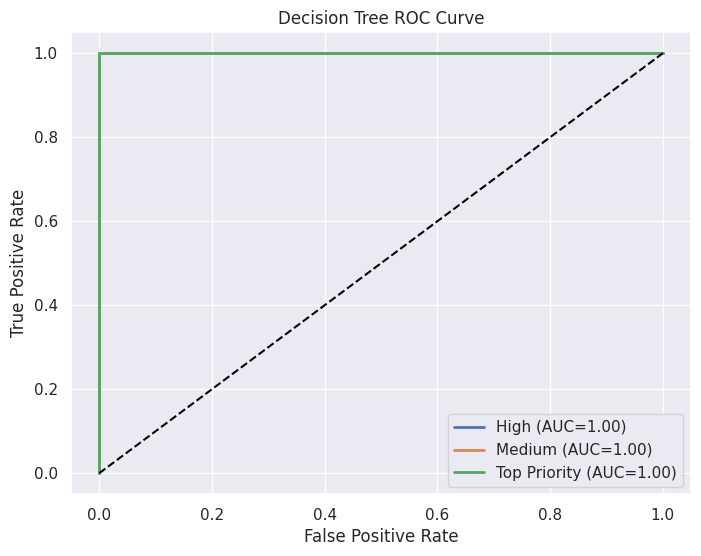



Random Forest

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1092
      Medium       1.00      1.00      1.00       884
Top Priority       1.00      0.99      1.00       124

    accuracy                           1.00      2100
   macro avg       1.00      1.00      1.00      2100
weighted avg       1.00      1.00      1.00      2100



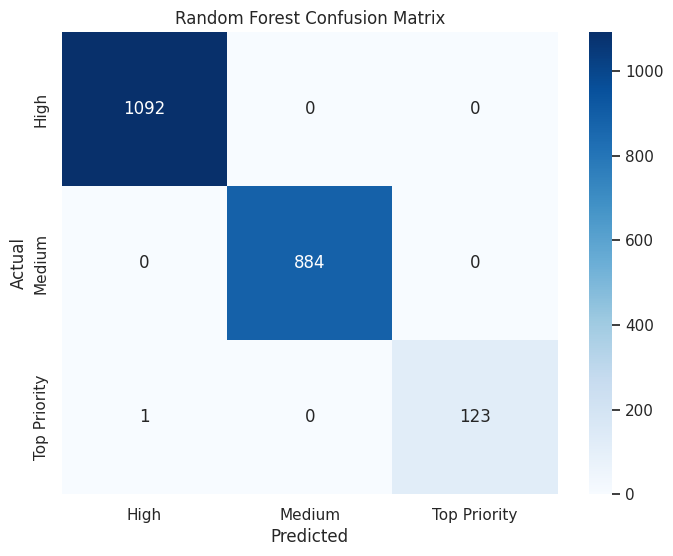

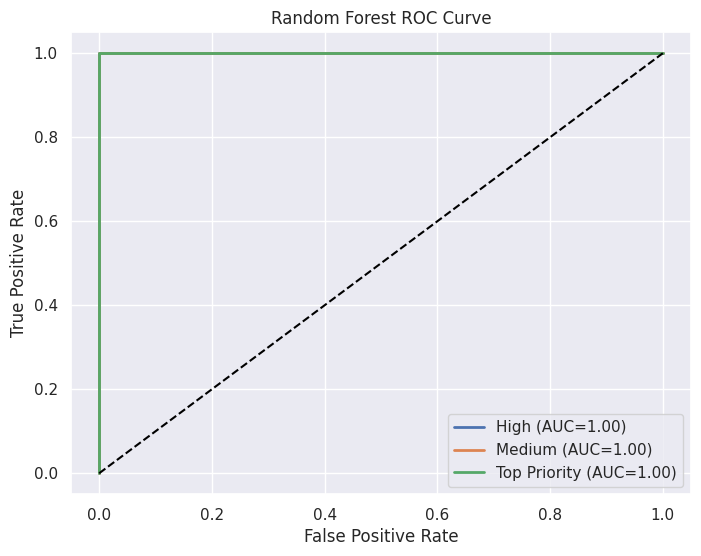



Gradient Boosting

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1092
      Medium       1.00      1.00      1.00       884
Top Priority       1.00      1.00      1.00       124

    accuracy                           1.00      2100
   macro avg       1.00      1.00      1.00      2100
weighted avg       1.00      1.00      1.00      2100



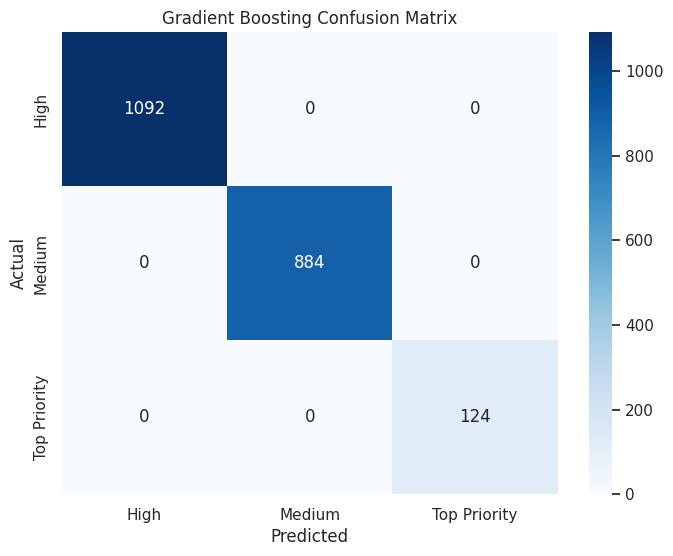

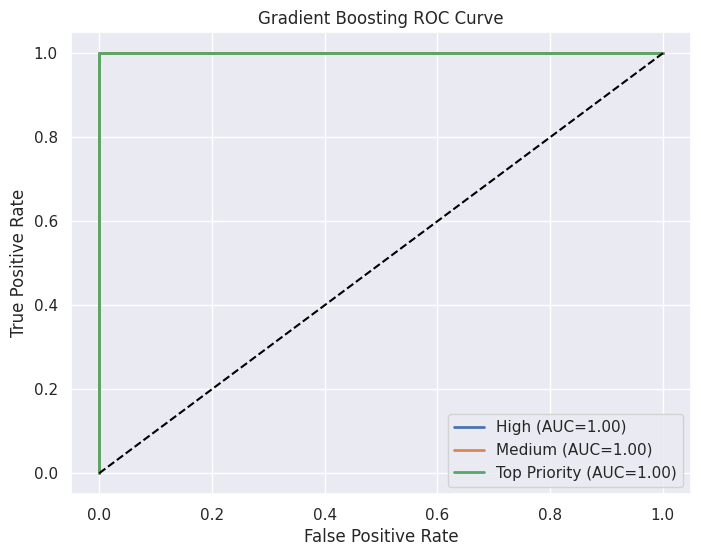



Extra Trees

Classification Report

              precision    recall  f1-score   support

        High       0.94      0.99      0.96      1092
      Medium       0.99      0.98      0.98       884
Top Priority       1.00      0.58      0.73       124

    accuracy                           0.96      2100
   macro avg       0.97      0.85      0.89      2100
weighted avg       0.96      0.96      0.96      2100



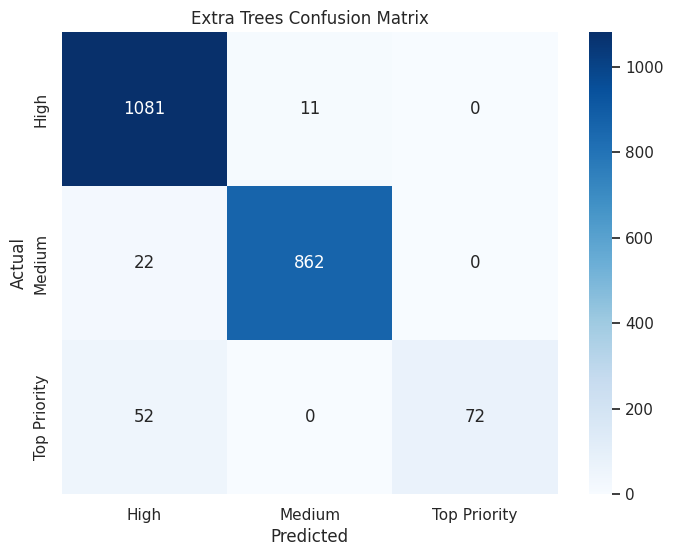

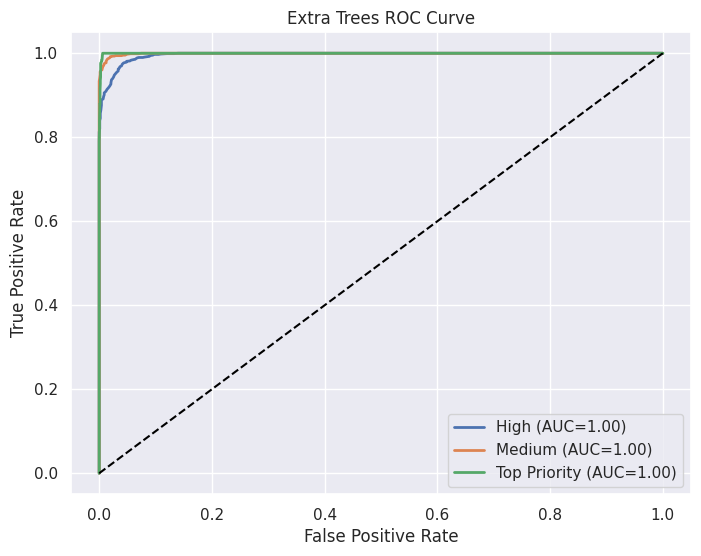



AdaBoost

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1092
      Medium       1.00      1.00      1.00       884
Top Priority       1.00      1.00      1.00       124

    accuracy                           1.00      2100
   macro avg       1.00      1.00      1.00      2100
weighted avg       1.00      1.00      1.00      2100



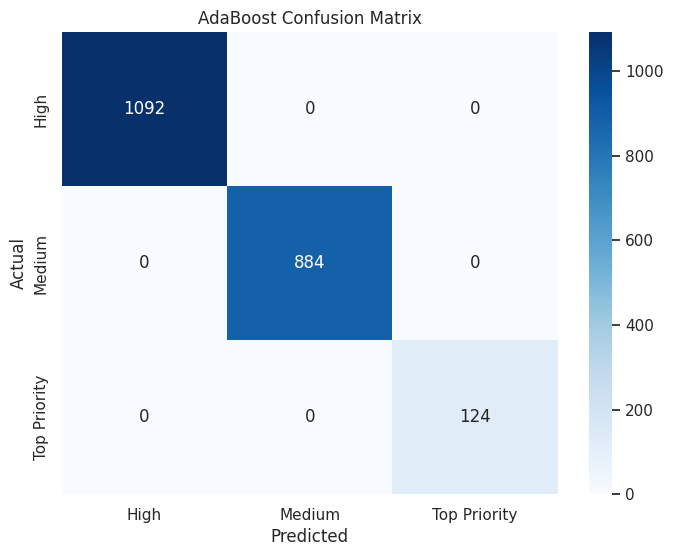

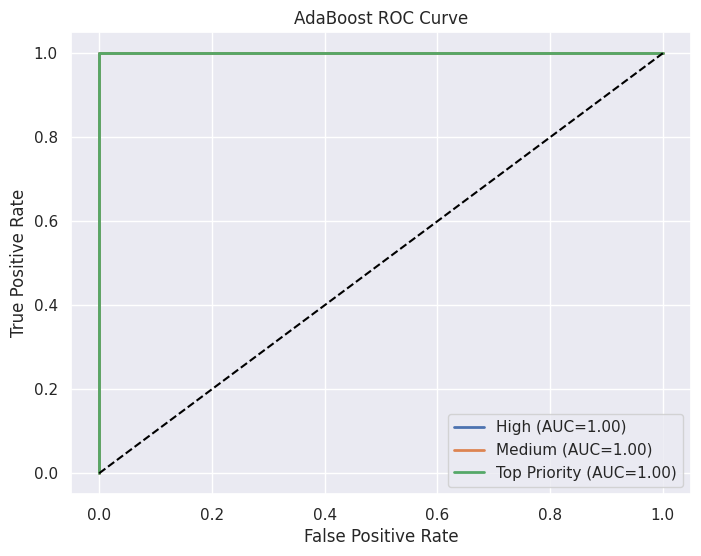



KNN

Classification Report

              precision    recall  f1-score   support

        High       0.78      0.89      0.83      1092
      Medium       0.86      0.80      0.83       884
Top Priority       0.94      0.23      0.37       124

    accuracy                           0.82      2100
   macro avg       0.86      0.64      0.68      2100
weighted avg       0.83      0.82      0.81      2100



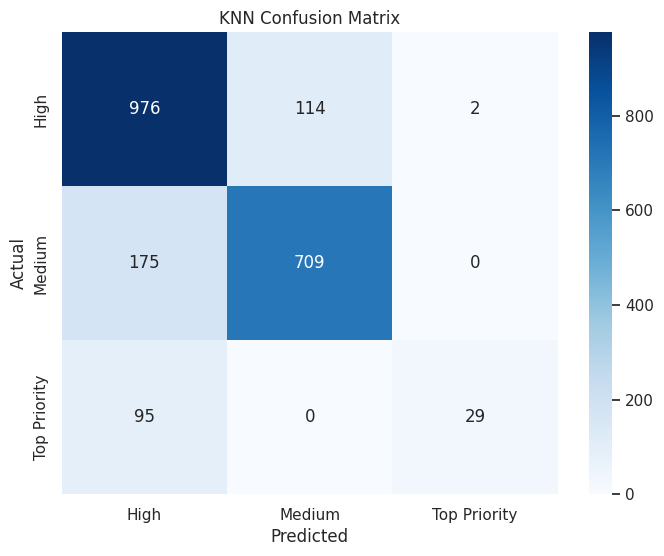

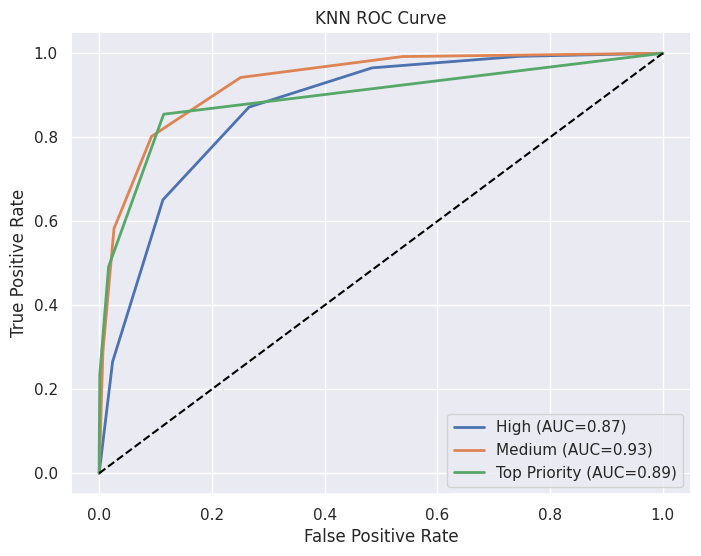



SVM

Classification Report

              precision    recall  f1-score   support

        High       0.94      0.98      0.96      1092
      Medium       0.98      0.96      0.97       884
Top Priority       0.99      0.74      0.85       124

    accuracy                           0.96      2100
   macro avg       0.97      0.90      0.93      2100
weighted avg       0.96      0.96      0.96      2100



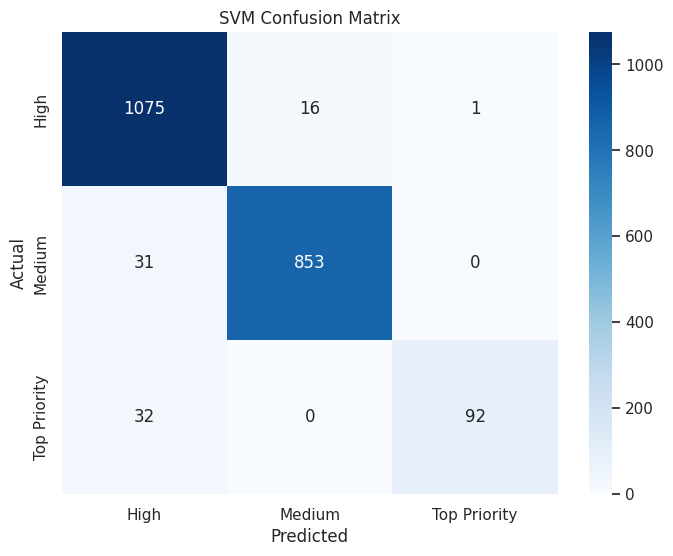

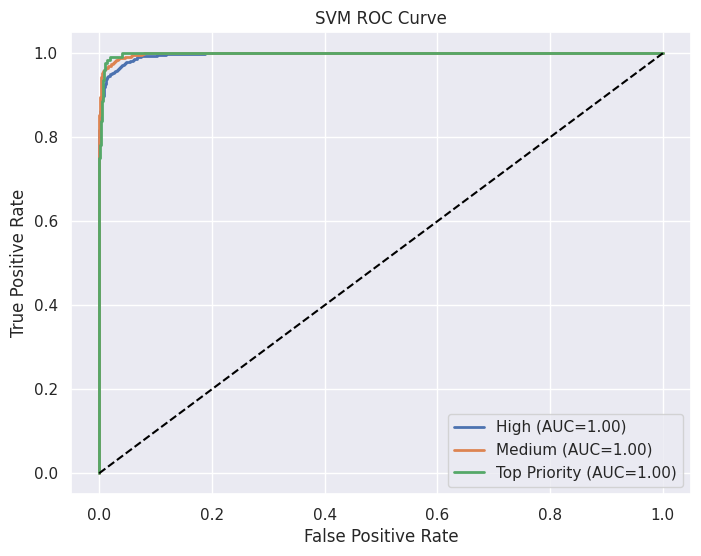



Naive Bayes

Classification Report

              precision    recall  f1-score   support

        High       0.97      0.97      0.97      1092
      Medium       0.99      0.97      0.98       884
Top Priority       0.87      0.95      0.91       124

    accuracy                           0.97      2100
   macro avg       0.94      0.97      0.95      2100
weighted avg       0.97      0.97      0.97      2100



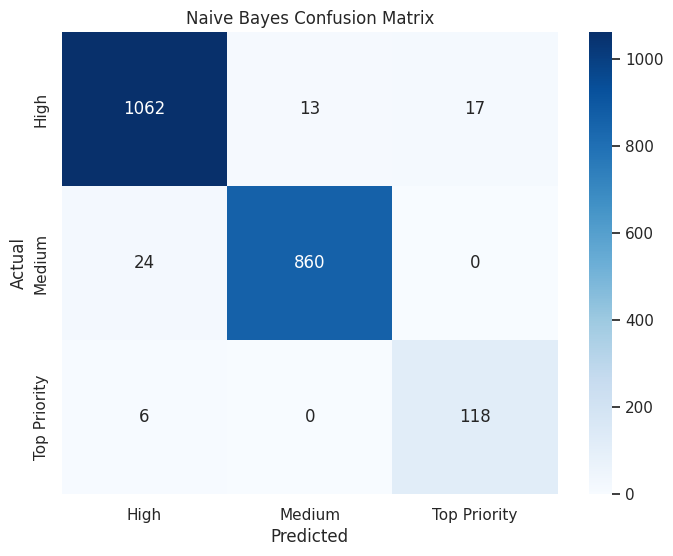

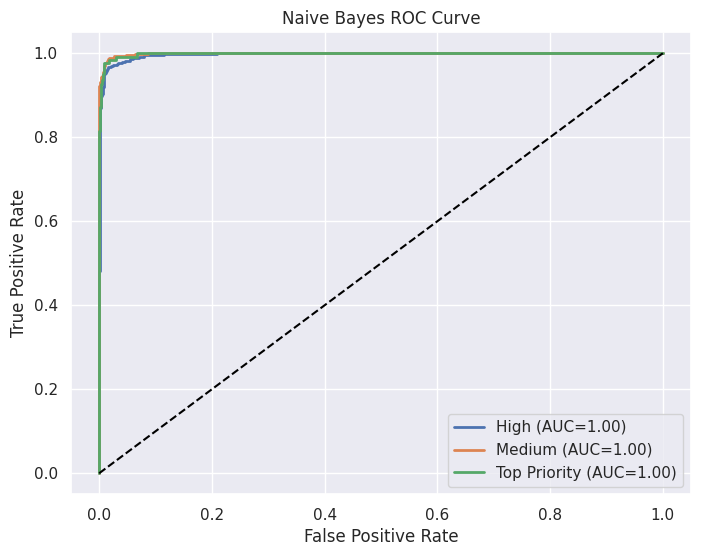



MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score
1        Decision Tree  1.000000   1.000000  1.000000  1.000000
5             AdaBoost  1.000000   1.000000  1.000000  1.000000
3    Gradient Boosting  1.000000   1.000000  1.000000  1.000000
2        Random Forest  0.999524   0.999524  0.999524  0.999523
0  Logistic Regression  0.990952   0.990972  0.990952  0.990890
8          Naive Bayes  0.971429   0.972010  0.971429  0.971606
7                  SVM  0.961905   0.962827  0.961905  0.961079
4          Extra Trees  0.959524   0.961380  0.959524  0.956757
6                  KNN  0.816190   0.825201  0.816190  0.805928


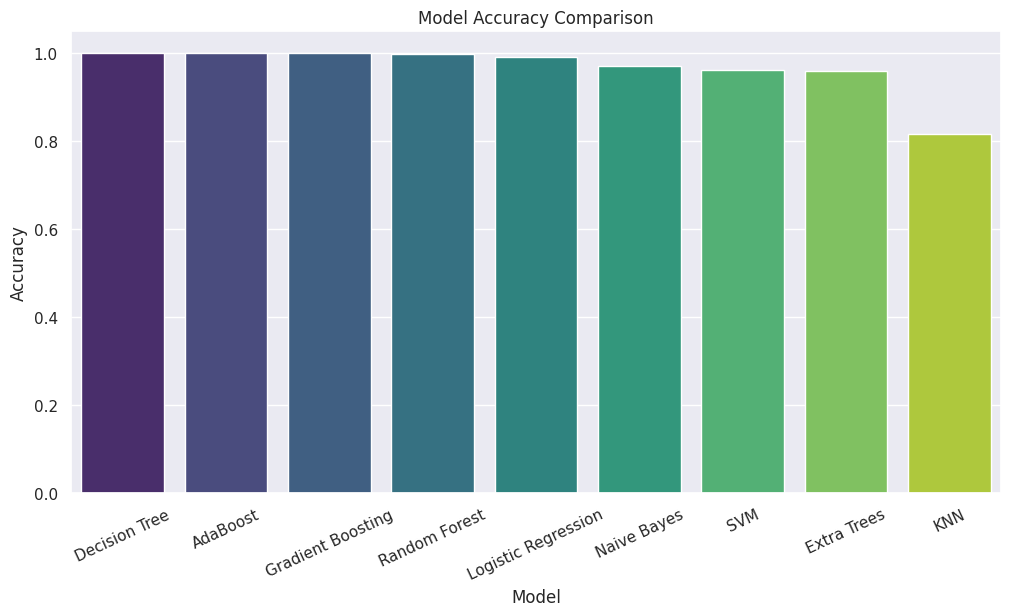

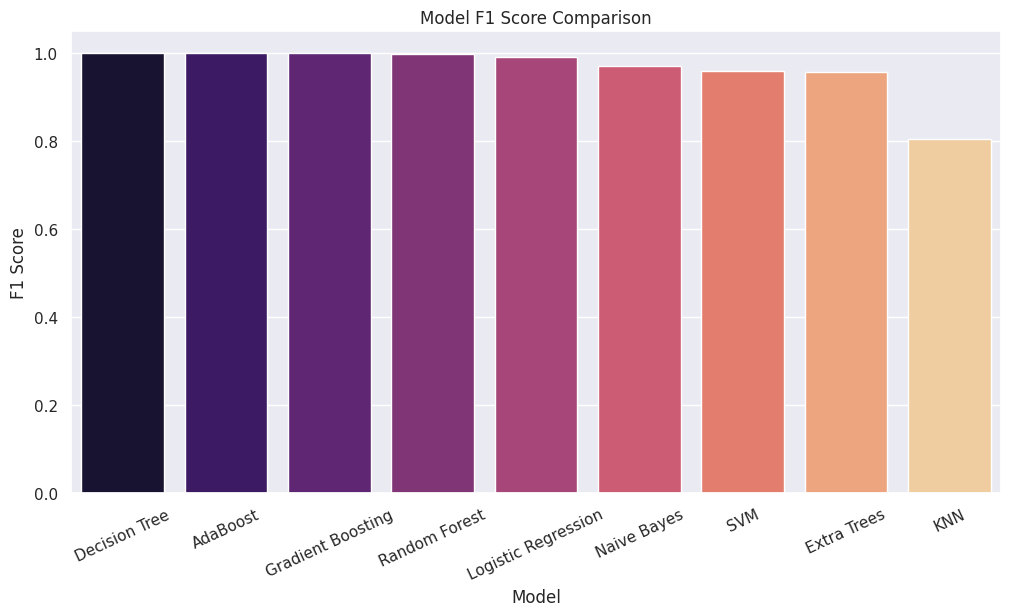

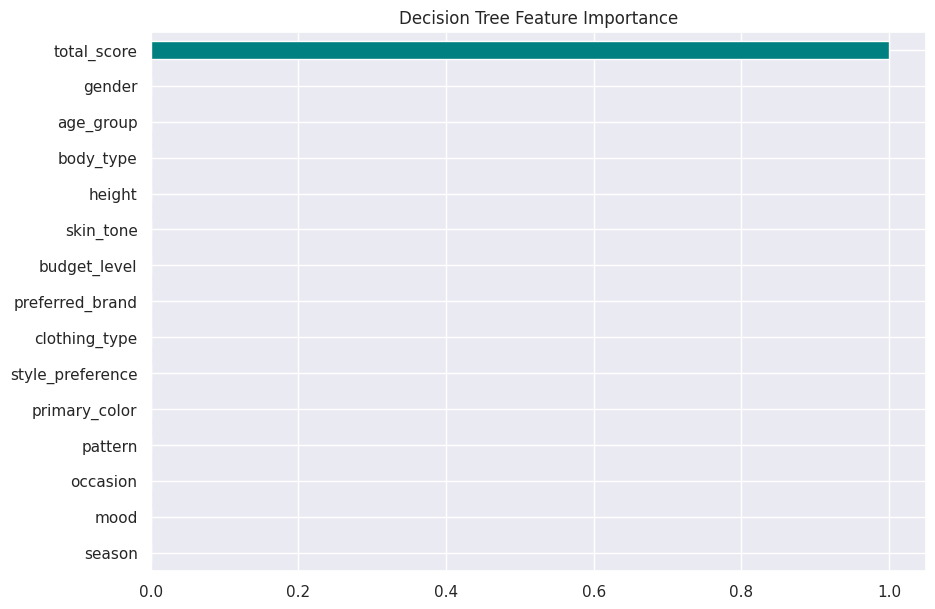

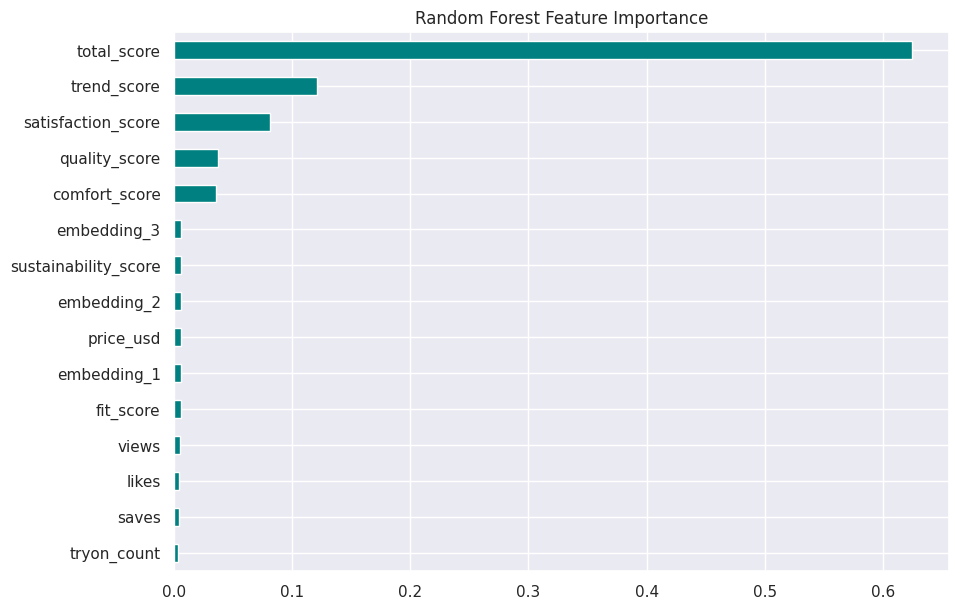

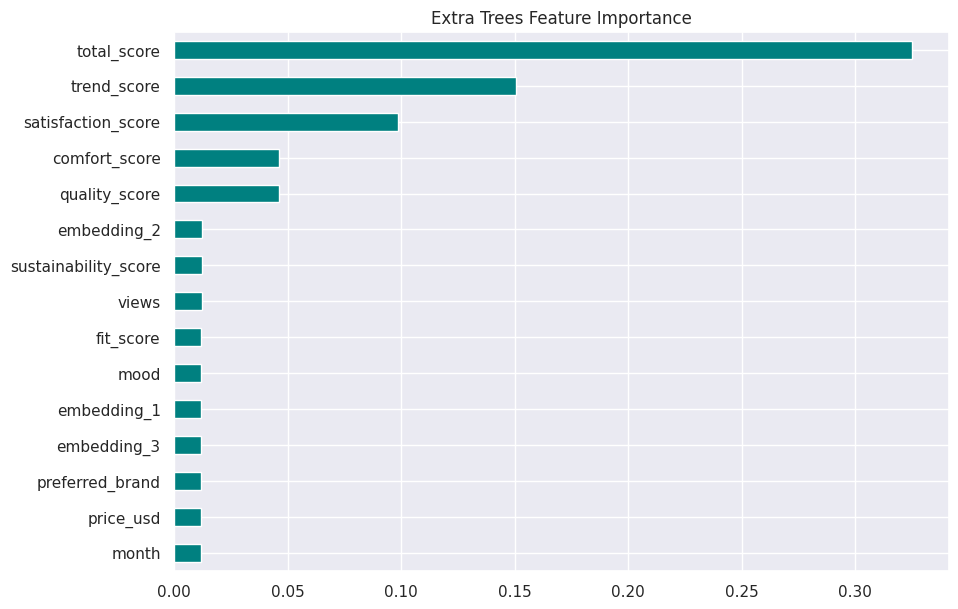

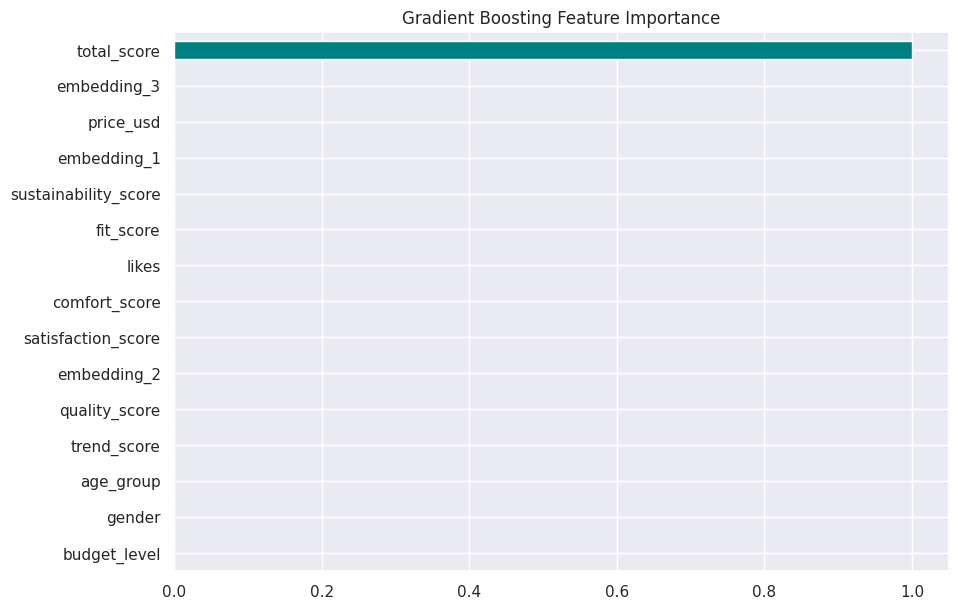



BEST MODEL
Model        Decision Tree
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1 Score               1.0
Name: 1, dtype: object

Best Model Name : Decision Tree
Accuracy        : 1.0
Precision       : 1.0
Recall          : 1.0
F1 Score        : 1.0

Model comparison saved as 'Model_Comparison.csv'


MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [13]:
# ============================================================
# PART 2 : MODEL EVALUATION
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

# ============================================================
# EVALUATE EVERY MODEL
# ============================================================

for model_name, model in trained_models.items():

    print("\n")
    print("="*100)
    print(model_name)
    print("="*100)

    prediction = model.predict(X_test)

    # ----------------------------------------------------------
    # CLASSIFICATION REPORT (FIXED)
    # ----------------------------------------------------------

    labels = np.unique(np.concatenate([y_test, prediction]))

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            prediction,
            labels=labels,
            target_names=target_encoder.inverse_transform(labels),
            zero_division=0
        )
    )

    # ----------------------------------------------------------
    # CONFUSION MATRIX
    # ----------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        prediction,
        labels=labels
    )

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_encoder.inverse_transform(labels),
        yticklabels=target_encoder.inverse_transform(labels)
    )

    plt.title(model_name + " Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ----------------------------------------------------------
    # ROC CURVE
    # ----------------------------------------------------------

    if hasattr(model, "predict_proba"):

        probability = model.predict_proba(X_test)

        classes = np.arange(len(target_encoder.classes_))

        y_binary = label_binarize(
            y_test,
            classes=classes
        )

        plt.figure(figsize=(8,6))

        for i in range(len(classes)):

            # Skip class if not present
            if np.sum(y_binary[:, i]) == 0:
                continue

            fpr, tpr, _ = roc_curve(
                y_binary[:, i],
                probability[:, i]
            )

            roc_auc = auc(fpr, tpr)

            plt.plot(
                fpr,
                tpr,
                linewidth=2,
                label=f"{target_encoder.classes_[i]} (AUC={roc_auc:.2f})"
            )

        plt.plot(
            [0,1],
            [0,1],
            linestyle="--",
            color="black"
        )

        plt.title(model_name + " ROC Curve")

        plt.xlabel("False Positive Rate")

        plt.ylabel("True Positive Rate")

        plt.legend()

        plt.grid(True)

        plt.show()

# ============================================================
# MODEL COMPARISON
# ============================================================

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*80)
print("MODEL COMPARISON")
print("="*80)

print(results_df)

# ============================================================
# BAR CHART OF ACCURACY
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.xticks(rotation=25)

plt.title("Model Accuracy Comparison")

plt.show()

# ============================================================
# BAR CHART OF F1 SCORE
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score",
    palette="magma"
)

plt.xticks(rotation=25)

plt.title("Model F1 Score Comparison")

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_names = X.columns

tree_models = [
    "Decision Tree",
    "Random Forest",
    "Extra Trees",
    "Gradient Boosting"
]

for model_name in tree_models:

    if model_name in trained_models:

        model = trained_models[model_name]

        if hasattr(model, "feature_importances_"):

            importance = pd.Series(
                model.feature_importances_,
                index=feature_names
            )

            importance = importance.sort_values(
                ascending=False
            )

            plt.figure(figsize=(10,7))

            importance.head(15).plot(
                kind="barh",
                color="teal"
            )

            plt.title(model_name + " Feature Importance")

            plt.gca().invert_yaxis()

            plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best = results_df.iloc[0]

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(best)

print("\nBest Model Name :", best["Model"])
print("Accuracy        :", round(best["Accuracy"],4))
print("Precision       :", round(best["Precision"],4))
print("Recall          :", round(best["Recall"],4))
print("F1 Score        :", round(best["F1 Score"],4))

# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv("Model_Comparison.csv", index=False)

print("\nModel comparison saved as 'Model_Comparison.csv'")

print("\n")
print("="*80)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)

## Thanks.........Please Upvote